# 🌊 Brahmapur Coastline Erosion Analysis Pipeline
## Ganjam District, Odisha — Bay of Bengal | 5-Year Study: 2019–2024

---

### About this Notebook

This notebook contains the **complete data analysis pipeline** for monitoring coastal erosion  
along the Brahmapur (Berhampur) coastline using multi-temporal satellite imagery.

**Study Area:** Brahmapur coast, Ganjam district, Odisha, India  
**Temporal Coverage:** 2013 – 2024 (12-year window)  
**Primary Satellite Sources:** Sentinel-2 MSI (10m) + Landsat 8/9 OLI (30m)  
**Platform for Image Processing:** Google Earth Engine (GEE)

---

### What this notebook covers

| Module | Analysis | Key Output |
|--------|----------|------------|
| 0 | Setup & Imports | Environment ready |
| 1 | Shoreline Change Stats (DSAS) | EPR, NSM, LRR per transect |
| 2 | Spectral Index Time Series | NDWI, MNDWI, NDVI, BSI trends |
| 3 | Confusion Matrix & Accuracy | OA, Kappa, PA, UA |
| 4 | Erosion Hotspot Classification | Risk map & table |
| 5 | Correlation: Erosion vs Climate | Rainfall, waves, storms |
| 6 | Paper-ready Summary Table | All key metrics combined |

---


---


---
## Module 0 — Environment Setup & Imports

Install and import all required libraries.  
Run this cell first before anything else.


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# INSTALL DEPENDENCIES
# Run this once. If you're in Google Colab, these are mostly pre-installed.
# ─────────────────────────────────────────────────────────────────────────────
%pip install numpy pandas matplotlib seaborn scikit-learn scipy geopandas rasterio


Note: you may need to restart the kernel to use updated packages.


In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# STANDARD SCIENTIFIC LIBRARIES
# ─────────────────────────────────────────────────────────────────────────────
import numpy as np          # Numerical arrays and math operations
import pandas as pd         # DataFrames — the core data structure we'll use
import os                   # File system operations (creating output folders)
import warnings             # Suppress non-critical library warnings

# ─────────────────────────────────────────────────────────────────────────────
# VISUALISATION
# ─────────────────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt        # Core plotting library
import matplotlib.colors as mcolors    # Color utilities for custom maps
from matplotlib.patches import Patch   # For custom legend entries
import seaborn as sns                  # Statistical visualisation (heatmaps etc.)

# ─────────────────────────────────────────────────────────────────────────────
# GEOSPATIAL (uncomment when you have real GeoJSON / Shapefile data)
# ─────────────────────────────────────────────────────────────────────────────
# import geopandas as gpd      # Vector data: shapefiles, GeoJSON, spatial joins
# import rasterio              # Raster data: read/write GeoTIFF files
# from rasterio.features import shapes   # Convert raster masks to vector polygons
# from rasterio.mask import mask         # Clip rasters to an AOI polygon

# ─────────────────────────────────────────────────────────────────────────────
# STATISTICS & MACHINE LEARNING
# ─────────────────────────────────────────────────────────────────────────────
from sklearn.metrics import (
    confusion_matrix,       # Build the NxN error matrix
    cohen_kappa_score       # Kappa coefficient — measures inter-rater agreement
)
from scipy import stats             # General statistical functions
from scipy.stats import pearsonr    # Pearson correlation coefficient + p-value

# ─────────────────────────────────────────────────────────────────────────────
# GLOBAL CONFIGURATION
# ─────────────────────────────────────────────────────────────────────────────
warnings.filterwarnings("ignore")   # Hide deprecation warnings for cleaner output

# Create output folder (will not overwrite if it already exists)
os.makedirs("outputs", exist_ok=True)

# Matplotlib global style — clean, publication-friendly
plt.rcParams.update({
    "figure.dpi"         : 150,      # High-res figures for paper submission
    "axes.spines.top"    : False,    # Remove top border (cleaner look)
    "axes.spines.right"  : False,    # Remove right border
    "font.family"        : "sans-serif",
    "axes.titlesize"     : 13,
    "axes.labelsize"     : 11,
    "savefig.bbox"       : "tight",  # Auto-trim whitespace when saving
})

# ─────────────────────────────────────────────────────────────────────────────
# STUDY AREA CONSTANTS
# These are used throughout the notebook for labelling and filtering
# ─────────────────────────────────────────────────────────────────────────────
YEARS = list(range(2013, 2025))   # 12-year study: 2013–2024
STUDY_AREA = "Brahmapur Coastline, Ganjam, Odisha"

# Approximate bounding box of your AOI (update with your precise coordinates)
AOI_BOUNDS = {
    "lat_min": 19.2221, "lat_max": 19.3906,
    "lon_min": 84.8433, "lon_max": 85.0599,
}

print("✅ All libraries imported successfully.")
print(f"   Study area : {STUDY_AREA}")
print(f"   Years      : {YEARS[0]} – {YEARS[-1]}")
print(f"   Outputs    : ./outputs/")


✅ All libraries imported successfully.
   Study area : Brahmapur Coastline, Ganjam, Odisha
   Years      : 2013 – 2024
   Outputs    : ./outputs/


---
## Module 1 — Shoreline Change Statistics (DSAS)

### What is DSAS?
**Digital Shoreline Analysis System (DSAS)** is a free USGS ArcGIS plug-in (also available standalone)  
that casts perpendicular transects along a baseline and calculates where your annual shorelines  
intersect each transect.

### Key metrics this module analyses:

| Metric | Full Name | What it means |
|--------|-----------|---------------|
| **EPR** | End Point Rate | Change rate (m/yr) between the earliest and latest shoreline only |
| **NSM** | Net Shoreline Movement | Total distance the shoreline moved (metres) over the full period |
| **LRR** | Linear Regression Rate | Best-fit slope (m/yr) across **all** annual shorelines — most robust |
| **SCE** | Shoreline Change Envelope | Maximum range of movement at each transect |
| **R²** | Regression goodness-of-fit | How well the LRR trend fits the data (0–1) |

### Classification thresholds used:
- **High Erosion**: LRR ≤ −1.0 m/yr  
- **Moderate Erosion**: −1.0 < LRR ≤ −0.3 m/yr  
- **Stable**: −0.3 < LRR < +0.3 m/yr  
- **Moderate Accretion**: +0.3 ≤ LRR < +1.0 m/yr  
- **High Accretion**: LRR ≥ +1.0 m/yr

### Real data format expected:
Your DSAS export CSV should have at minimum these columns:  
`TransectID, Longitude, Latitude, EPR_m_yr, NSM_m, LRR_m_yr, R2, SCE_m`


In [12]:
#=============================================================================
# MODULE 1 — CORRECTED DSAS PIPELINE
# Fixes: (1) coastal-only baseline via corridor clip
#         (2) signed distances — negative = erosion, positive = accretion
#         (3) distance sanity filter — removes inland pond hits
# =============================================================================
 
import os
import math
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy import stats
from shapely.ops import unary_union, linemerge, split
from shapely.geometry import (MultiPolygon, Polygon, MultiLineString,
                               LineString, Point, box)
 
# ─────────────────────────────────────────────────────────────────────────────
# CONFIG — update DATA_DIR to wherever your new shapefiles are downloaded
# ─────────────────────────────────────────────────────────────────────────────
DATA_DIR   = "/Users/tsukki/Downloads/GEE_Brahmapur"   # ← update this
OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)
 
YEARS      = list(range(2013, 2025))
STUDY_AREA = "Ganjam District Coastline, Odisha"
 
# Confirmed AOI
AOI = [84.8433, 19.2221, 85.0599, 19.3906]   # [W, S, E, N]
 
# Transect parameters
TRANSECT_SPACING = 250    # metres between transects along baseline
TRANSECT_LENGTH  = 2000   # metres — long enough to reach shoreline from baseline
                           # (increased from 1000m to be safe with new AOI)
MAX_VALID_DIST   = 500    # metres — distances beyond this are inland water, not coast
                           # tune down after checking your data if needed
 
# ─────────────────────────────────────────────────────────────────────────────
# 1A. BUILD CLEAN COASTAL BASELINE
# Problem before: baseline = full shoreline_2013.shp including inland ponds
# Fix: clip shoreline_2013 to a narrow coastal corridor (1km inland from
#      the ocean-facing edge of the AOI) before casting transects
# ─────────────────────────────────────────────────────────────────────────────
 
def extract_lines(geom):
    """Convert polygon/multipolygon to exterior linestring(s)."""
    if isinstance(geom, Polygon):
        return geom.exterior
    elif isinstance(geom, MultiPolygon):
        return linemerge([p.exterior for p in geom.geoms])
    elif isinstance(geom, MultiLineString):
        return linemerge(geom)
    elif isinstance(geom, LineString):
        return geom
    else:
        return geom.boundary
 
 
# Load 2013 shoreline
baseline_raw = gpd.read_file("/Users/tsukki/Downloads/GEE_Brahmapur/shoreline_2013.shp")
if baseline_raw.crs is None or baseline_raw.crs.to_epsg() != 32645:
    baseline_raw = baseline_raw.to_crs(epsg=32645)
 
# Build coastal corridor: 2km strip along the eastern (ocean-facing) edge of AOI
# The Ganjam coast runs NE-SW so "ocean side" is roughly east
# We keep geometry within 2km of the AOI eastern boundary
aoi_geom = gpd.GeoDataFrame(
    geometry=[box(AOI[0], AOI[1], AOI[2], AOI[3])],
    crs="EPSG:4326"
).to_crs(epsg=32645)
 
# Buffer inward 2km from eastern edge = keep only geometry near the coast
# Strategy: take the full AOI, shrink it 2km from the west only
# Done by buffering the eastern half of the AOI
aoi_proj = aoi_geom.geometry.values[0]
aoi_bounds = aoi_proj.bounds   # (minx, miny, maxx, maxy)
# Diagonal coastal strip matching the actual beach orientation
# Coast runs NE-SW: from (85.05, 19.39) top to (84.92, 19.22) bottom
# Use the same diagonal strip logic as GEE
from shapely.geometry import Polygon as ShapelyPolygon

coastal_strip = ShapelyPolygon([
    (85.015, 19.400),   # top-left  (was 85.005)
    (85.042, 19.400),   # top-right (unchanged)
    (84.878, 19.200),   # bottom-right (was 84.868)
    (84.840, 19.200),   # bottom-left  (was 84.830)
])
# Convert to projected CRS
coastal_strip_gdf = gpd.GeoDataFrame(
    geometry=[coastal_strip], crs="EPSG:4326"
).to_crs(epsg=32645)
coastal_corridor = coastal_strip_gdf
# Clip 2013 shoreline to coastal corridor only
baseline_clipped = gpd.clip(baseline_raw, coastal_corridor)
 
if len(baseline_clipped) == 0:
    raise ValueError(
        "Coastal corridor clip returned empty geometry. "
        "Check that DATA_DIR points to your NEW shapefiles extracted with the correct AOI. "
        "Do not run this with the old wrong-AOI shapefiles."
    )
 
baseline_union = unary_union(baseline_clipped.geometry.values)
baseline_union = extract_lines(baseline_union)
 
print(f"Baseline geometry type : {baseline_union.geom_type}")
print(f"Baseline length        : {baseline_union.length:.0f} m")
print(f"  ✅ Expected: 40,000–60,000 m (40–60 km for Ganjam coast)")
print(f"  ❌ If you see >100,000 m — inland contamination still present, check corridor width")

Baseline geometry type : MultiLineString
Baseline length        : 59700 m
  ✅ Expected: 40,000–60,000 m (40–60 km for Ganjam coast)
  ❌ If you see >100,000 m — inland contamination still present, check corridor width


In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# 1B. CAST TRANSECTS PERPENDICULAR TO BASELINE
# ─────────────────────────────────────────────────────────────────────────────
 
def cast_transects(baseline_geom, spacing, length):
    """
    Cast perpendicular transects along a linestring at regular spacing.
    Returns GeoDataFrame with columns: TransectID, geometry, Longitude, Latitude
    Each transect is centred on the baseline point and extends 'length/2' each side.
    """
    if isinstance(baseline_geom, MultiLineString):
        lines = list(baseline_geom.geoms)
    else:
        lines = [baseline_geom]
 
    transects = []
    tid = 0
    for line in lines:
        total_len = line.length
        d = 0.0
        while d <= total_len:
            pt = line.interpolate(d)
            # Get tangent direction
            d2 = min(d + 1.0, total_len)
            pt2 = line.interpolate(d2)
            dx = pt2.x - pt.x
            dy = pt2.y - pt.y
            norm = math.hypot(dx, dy)
            if norm == 0:
                d += spacing
                continue
            # Perpendicular direction
            px, py = -dy / norm, dx / norm
            half = length / 2
            # Transect: from landward side to ocean side
            start = Point(pt.x - px * half, pt.y - py * half)
            end   = Point(pt.x + px * half, pt.y + py * half)
            transect_line = LineString([start, end])
 
            # Coordinate of baseline midpoint in WGS84 for output table
            midpt_gdf = gpd.GeoDataFrame(geometry=[pt], crs="EPSG:32645").to_crs(epsg=4326)
            lon = midpt_gdf.geometry.x.values[0]
            lat = midpt_gdf.geometry.y.values[0]
 
            transects.append({
                "TransectID": tid,
                "Longitude" : round(lon, 6),
                "Latitude"  : round(lat, 6),
                "geometry"  : transect_line,
                # Store baseline point for signed distance computation
                "_baseline_pt": pt,
            })
            tid += 1
            d += spacing
 
    gdf = gpd.GeoDataFrame(transects, crs="EPSG:32645")
    return gdf
 
 
transects_gdf = cast_transects(baseline_union, spacing=TRANSECT_SPACING, length=TRANSECT_LENGTH)
print(f"\nCast {len(transects_gdf)} transects at {TRANSECT_SPACING}m spacing")


Cast 266 transects at 250m spacing


In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# 1C. COMPUTE SIGNED ANNUAL DISTANCES
# Sign convention:
#   Positive = shoreline moved SEAWARD from baseline  (accretion)
#   Negative = shoreline moved LANDWARD from baseline (erosion)
#
# How signing works:
#   The transect runs from landward end → seaward end.
#   We project the intersection point onto the transect and get its position
#   relative to the baseline midpoint. Points past midpoint toward ocean = +ve.
# ─────────────────────────────────────────────────────────────────────────────
 
dist_records = {"TransectID": transects_gdf["TransectID"].values}
 
for yr in YEARS:
    shp_path = f"{DATA_DIR}/shoreline_{yr}.shp"
    if not os.path.exists(shp_path):
        print(f"  WARNING: {shp_path} not found — year {yr} skipped")
        dist_records[f"dist_{yr}"] = np.full(len(transects_gdf), np.nan)
        continue
 
    annual = gpd.read_file(shp_path).to_crs(epsg=32645)
    annual_line = (annual.geometry.union_all()
                   if hasattr(annual.geometry, "union_all")
                   else annual.geometry.unary_union)
    annual_line = extract_lines(annual_line)
 
    dists = []
    for _, t_row in transects_gdf.iterrows():
        try:
            intersection = t_row.geometry.intersection(annual_line)
            if intersection.is_empty:
                dists.append(np.nan)
                continue
 
            # Get first intersection point
            if intersection.geom_type == "MultiPoint":
                int_pt = list(intersection.geoms)[0]
            elif intersection.geom_type == "Point":
                int_pt = intersection
            else:
                # LineString intersection (overlap) — take midpoint
                int_pt = intersection.centroid
 
            # Signed distance: project intersection onto transect
            # transect start = landward, end = seaward
            t_line = t_row.geometry
            t_len  = t_line.length
            proj_d = t_line.project(int_pt)   # distance from landward end
 
            # Baseline midpoint is at t_len/2
            # signed_dist = proj_d - (t_len/2)
            # positive → seaward of baseline (accretion)
            # negative → landward of baseline (erosion)
            signed = proj_d - (t_len / 2)
 
            # Sanity filter: if |distance| > MAX_VALID_DIST, it's an inland hit
            if abs(signed) > MAX_VALID_DIST:
                dists.append(np.nan)
            else:
                dists.append(round(signed, 2))
 
        except Exception:
            dists.append(np.nan)
 
    n_valid = sum(1 for d in dists if not np.isnan(d))
    print(f"  {yr}: {n_valid}/{len(transects_gdf)} valid intersections")
    dist_records[f"dist_{yr}"] = dists
 
df_annual = pd.DataFrame(dist_records)
df_annual.to_csv(f"{OUTPUT_DIR}/annual_distances_processed.csv", index=False)
print(f"\nSaved: {OUTPUT_DIR}/annual_distances_processed.csv")

  2013: 246/266 valid intersections
  2014: 195/266 valid intersections
  2015: 156/266 valid intersections
  2016: 157/266 valid intersections
  2017: 155/266 valid intersections
  2018: 170/266 valid intersections
  2019: 196/266 valid intersections
  2020: 177/266 valid intersections
  2021: 188/266 valid intersections
  2022: 174/266 valid intersections
  2023: 160/266 valid intersections
  2024: 148/266 valid intersections

Saved: outputs/annual_distances_processed.csv


In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# 1D. COMPUTE DSAS STATISTICS
# EPR  = avg(2022-2024) - avg(2013-2015) / 11  signed — negative = erosion
# NSM  = avg(2022-2024) - avg(2013-2015)        signed net movement in metres
# LRR  = OLS slope across all 12 years          signed — most robust metric
# SCE  = max(dist) - min(dist)                  always positive — total envelope
# ─────────────────────────────────────────────────────────────────────────────

year_cols = [f"dist_{y}" for y in YEARS]
years_arr = np.array(YEARS)

results = []
for _, row in df_annual.iterrows():
    dists = row[year_cols].values.astype(float)
    valid = ~np.isnan(dists)
    tid   = row["TransectID"]

    # EPR and NSM — use 3-year averages at each end to reduce endpoint noise
    d_start = np.nanmean([dists[0], dists[1], dists[2]])    # avg 2013-2015
    d_end   = np.nanmean([dists[9], dists[10], dists[11]])  # avg 2022-2024

    if not np.isnan(d_start) and not np.isnan(d_end):
        epr = round((d_end - d_start) / 11, 3)
        nsm = round(d_end - d_start, 3)
    else:
        epr = nsm = np.nan

    # LRR via OLS — minimum 5 valid years
    if valid.sum() >= 5:
        slope, intercept, r, _, se = stats.linregress(years_arr[valid], dists[valid])
        lrr    = round(slope, 3)
        lrr_r2 = round(r ** 2, 4)
    else:
        lrr = lrr_r2 = np.nan

    # SCE
    sce = round(float(np.nanmax(dists) - np.nanmin(dists)), 3) if valid.sum() >= 2 else np.nan

    results.append({
        "TransectID" : tid,
        "Longitude"  : transects_gdf.loc[transects_gdf["TransectID"] == tid, "Longitude"].values[0],
        "Latitude"   : transects_gdf.loc[transects_gdf["TransectID"] == tid, "Latitude"].values[0],
        "EPR_m_yr"   : epr,
        "NSM_m"      : nsm,
        "LRR_m_yr"   : lrr,
        "LRR_R2"     : lrr_r2,
        "SCE_m"      : sce,
        "n_valid"    : int(valid.sum()),
    })

dsas_df = pd.DataFrame(results)
dsas_df = dsas_df.dropna(subset=["LRR_m_yr"])

# Only filter physically impossible LRR
dsas_df = dsas_df[dsas_df['LRR_m_yr'].between(-8, 8)]

def classify_lrr(lrr):
    if lrr <= -1.0:   return "High Erosion"
    elif lrr < -0.3:  return "Moderate Erosion"
    elif lrr <= 0.3:  return "Stable"
    elif lrr < 1.0:   return "Moderate Accretion"
    else:             return "High Accretion"

dsas_df["Class"] = dsas_df["LRR_m_yr"].apply(classify_lrr)
dsas_df.to_csv(f"{OUTPUT_DIR}/dsas_transects_classified.csv", index=False)

print(f"\n{'='*55}")
print(f"  DSAS SUMMARY — {STUDY_AREA}")
print(f"{'='*55}")
print(f"  Total transects analysed : {len(dsas_df)}")
print(f"  Mean LRR                 : {dsas_df['LRR_m_yr'].mean():.3f} m/yr")
print(f"  Mean EPR                 : {dsas_df['EPR_m_yr'].mean():.3f} m/yr")
print(f"  Max erosion  (LRR)       : {dsas_df['LRR_m_yr'].min():.3f} m/yr")
print(f"  Max accretion (LRR)      : {dsas_df['LRR_m_yr'].max():.3f} m/yr")
print(f"  Net Shoreline Movement   : {dsas_df['NSM_m'].mean():.1f} m (mean)")
print(f"\n  Class breakdown:")
print(dsas_df["Class"].value_counts().to_string())
print(f"\nSaved: {OUTPUT_DIR}/dsas_transects_classified.csv")


  DSAS SUMMARY — Ganjam District Coastline, Odisha
  Total transects analysed : 119
  Mean LRR                 : -0.222 m/yr
  Mean EPR                 : -0.082 m/yr
  Max erosion  (LRR)       : -7.867 m/yr
  Max accretion (LRR)      : 7.832 m/yr
  Net Shoreline Movement   : -0.9 m (mean)

  Class breakdown:
Class
High Accretion        38
High Erosion          36
Stable                24
Moderate Erosion      12
Moderate Accretion     9

Saved: outputs/dsas_transects_classified.csv


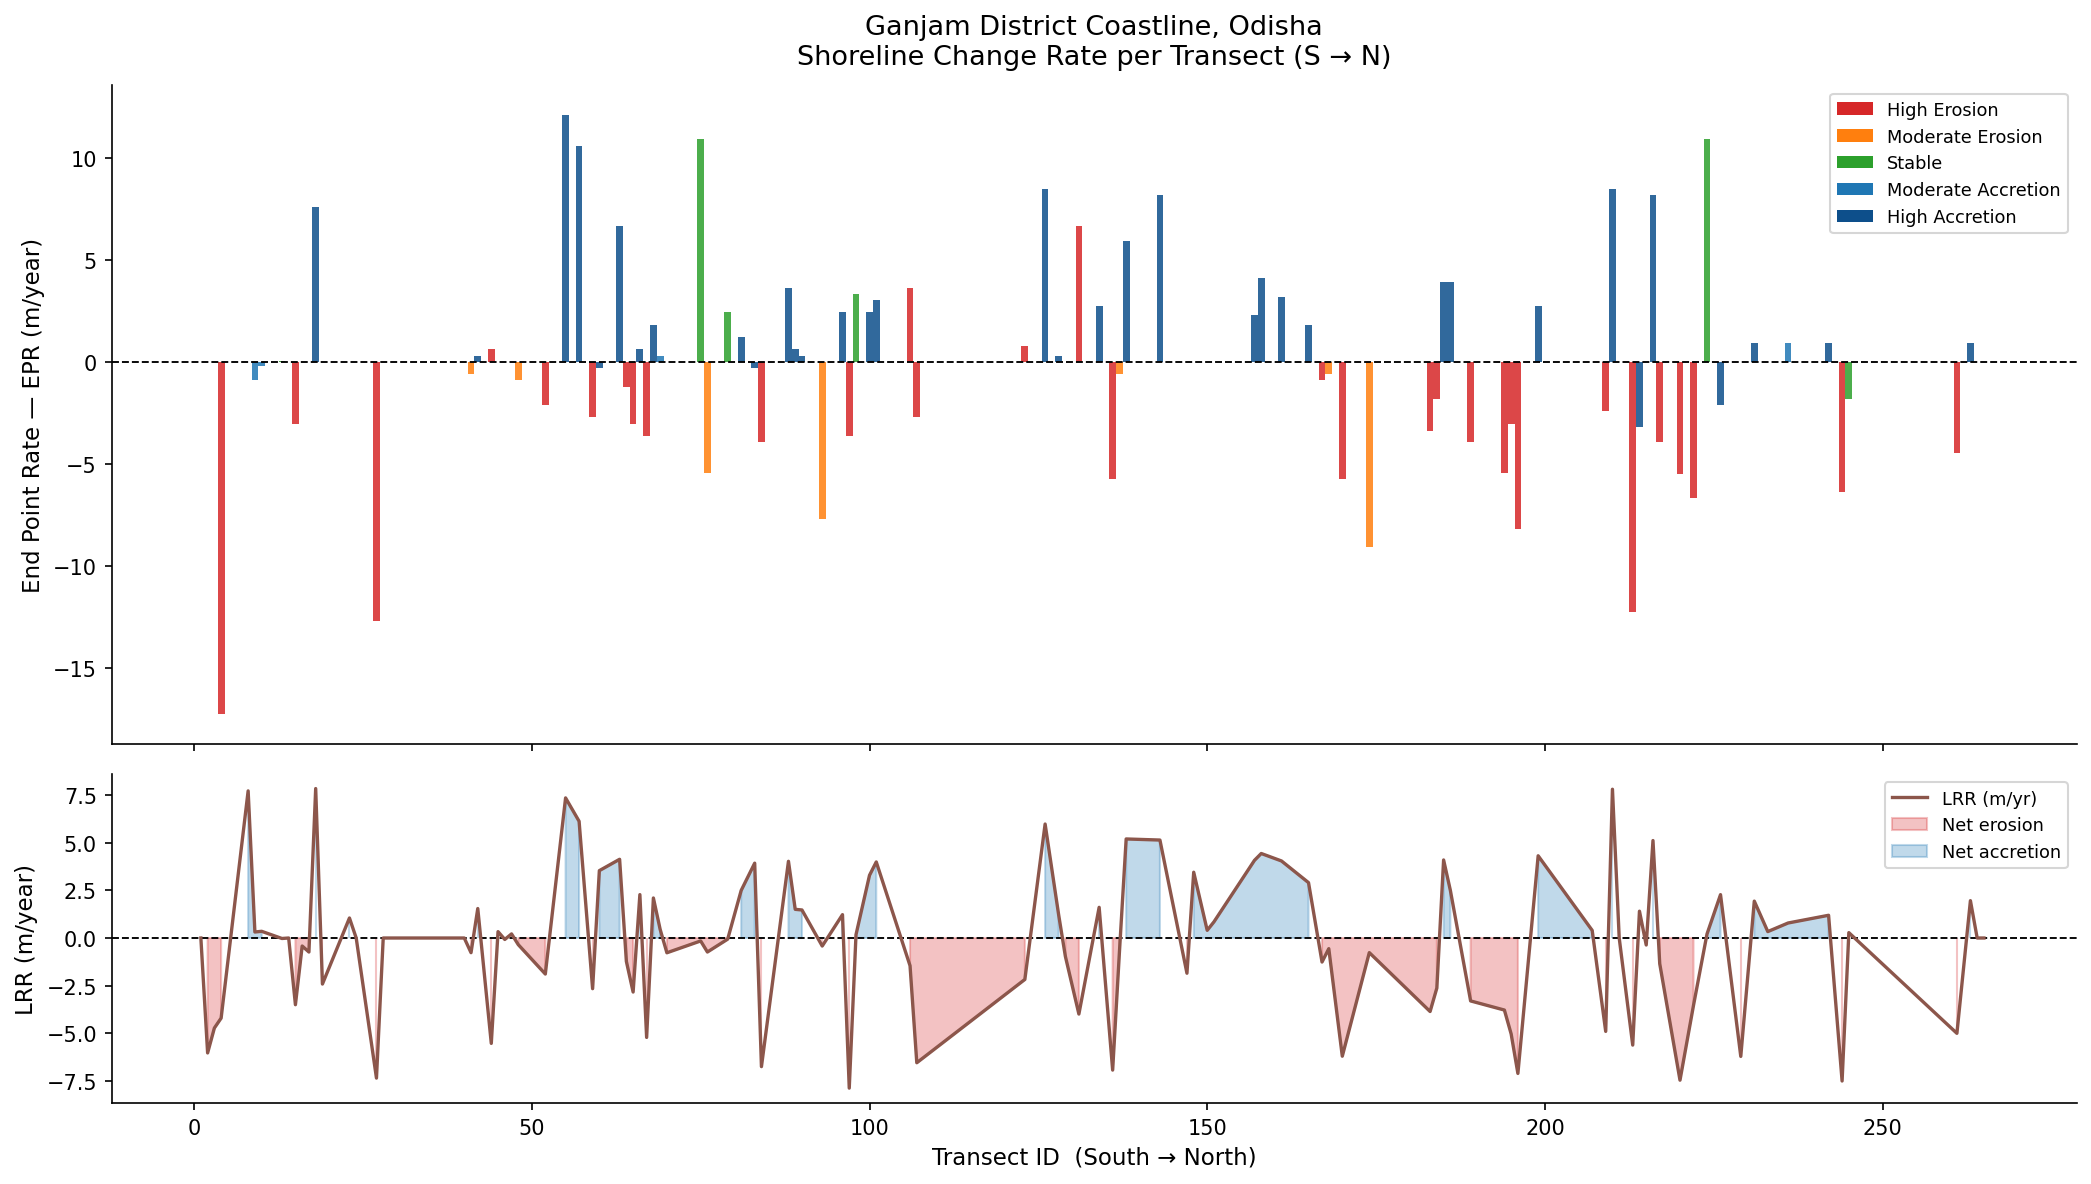

Saved: outputs/1_shoreline_change_stats.png


In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# 1E. VISUALISE — EPR bar chart + LRR trend line
# ─────────────────────────────────────────────────────────────────────────────
 
CLASS_COLORS = {
    "High Erosion"       : "#D62728",
    "Moderate Erosion"   : "#FF7F0E",
    "Stable"             : "#2CA02C",
    "Moderate Accretion" : "#1F77B4",
    "High Accretion"     : "#0D4F8B",
}
 
bar_colors = dsas_df["Class"].map(CLASS_COLORS).fillna("#999999")
 
fig, axes = plt.subplots(2, 1, figsize=(14, 8),
                          gridspec_kw={"height_ratios": [2, 1]}, sharex=True)
 
ax1 = axes[0]
ax1.bar(dsas_df["TransectID"], dsas_df["EPR_m_yr"],
        color=bar_colors, width=1.0, alpha=0.85, zorder=2)
ax1.axhline(0, color="black", linewidth=0.9, linestyle="--", zorder=3)
ax1.set_ylabel("End Point Rate — EPR (m/year)")
ax1.set_title(f"{STUDY_AREA}\nShoreline Change Rate per Transect (S → N)", pad=10)
legend_patches = [Patch(facecolor=v, label=k) for k, v in CLASS_COLORS.items()]
ax1.legend(handles=legend_patches, fontsize=8.5, loc="upper right", framealpha=0.8)
 
ax2 = axes[1]
lrr_valid = dsas_df.dropna(subset=["LRR_m_yr"])
ax2.plot(lrr_valid["TransectID"], lrr_valid["LRR_m_yr"],
         color="#8C564B", linewidth=1.6, label="LRR (m/yr)", zorder=3)
ax2.fill_between(lrr_valid["TransectID"], lrr_valid["LRR_m_yr"], 0,
                 where=(lrr_valid["LRR_m_yr"] < 0),
                 alpha=0.28, color="#D62728", label="Net erosion")
ax2.fill_between(lrr_valid["TransectID"], lrr_valid["LRR_m_yr"], 0,
                 where=(lrr_valid["LRR_m_yr"] > 0),
                 alpha=0.28, color="#1F77B4", label="Net accretion")
ax2.axhline(0, color="black", linewidth=0.9, linestyle="--")
ax2.set_xlabel("Transect ID  (South → North)")
ax2.set_ylabel("LRR (m/year)")
ax2.legend(fontsize=8.5, loc="upper right", framealpha=0.8)
 
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/1_shoreline_change_stats.png", dpi=150)
plt.show()
print(f"Saved: {OUTPUT_DIR}/1_shoreline_change_stats.png")

---
## Module 2 — Spectral Index Time Series (NDWI, MNDWI, NDVI, BSI)

### What are these indices?

| Index | Formula | What it detects |
|-------|---------|-----------------|
| **NDWI** | (Green − NIR) / (Green + NIR) | Open water bodies; values > 0 = water |
| **MNDWI** | (Green − SWIR) / (Green + SWIR) | Modified water index — better for coasts, reduces built-up noise |
| **NDVI** | (NIR − Red) / (NIR + Red) | Green vegetation; declining trend = coastal vegetation loss |
| **BSI** | ((SWIR+Red)−(NIR+Blue)) / ((SWIR+Red)+(NIR+Blue)) | Bare soil / sediment; rising trend = exposed sediment, erosion |

### How to get these values from GEE
In Google Earth Engine, after computing index rasters:
```javascript
// Example: export mean NDWI per year as CSV
var stats = ndwi_image.reduceRegion({
  reducer: ee.Reducer.mean(),
  geometry: aoi,
  scale: 10,
  maxPixels: 1e9
});
Export.table.toDrive({collection: stats, description: 'ndwi_2019'});
```
Repeat for each year and each index → you get 24 values (4 indices × 6 years).

### What to look for:
- **NDWI / MNDWI rising** → more water pixels = shoreline retreating landward  
- **NDVI declining** → vegetation being lost to wave action or inundation  
- **BSI rising** → more bare sediment exposed = active erosion surface


In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# 2A. LOAD SPECTRAL INDEX DATA
# One row per year, one column per index (mean value across AOI)
# ─────────────────────────────────────────────────────────────────────────────

 
import pandas as pd

# Module 0 — update this
YEARS = [2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]

# ── REAL DATA ─────────────────────────────────────────────────────
df_indices = pd.read_csv("/Users/tsukki/Downloads/GEE_Brahmapur/index_timeseries_12yr.csv")

# GEE exports two junk columns — drop them if present
df_indices = df_indices.drop(columns=['.geo', 'system:index'], errors='ignore')

# Make sure Year is integer and rows are sorted oldest to newest
df_indices['Year'] = df_indices['Year'].astype(int)
df_indices = df_indices.sort_values('Year').reset_index(drop=True)

# Quick sanity check
print(df_indices)

# ── Derived columns: year-on-year change rates ────────────────────────────────
# pct_change() computes (current - previous) / previous × 100
df_indices["NDVI_change_pct"] = df_indices["NDVI"].pct_change() * 100
# diff() computes absolute difference from previous row
df_indices["BSI_change"]      = df_indices["BSI"].diff()

print("Spectral Index Time Series Table:")
print(df_indices.round(4).to_string(index=False))


         BSI     MNDWI      NDVI      NDWI       Sensor  Year
0   0.039578 -0.037602  0.147976  0.002354  Landsat8_C2  2013
1  -0.043939 -0.035936  0.223366 -0.058777  Landsat8_C2  2014
2   0.465209 -0.041318  0.207034 -0.121672  Landsat8_C2  2015
3  -0.051777 -0.048478  0.214468 -0.130411  Landsat8_C2  2016
4  -0.099290 -0.027672  0.212477 -0.164436    Sentinel2  2017
5  -0.096344 -0.010384  0.180929 -0.131903    Sentinel2  2018
6  -0.121517  0.024827  0.191306 -0.128402    Sentinel2  2019
7  -0.104859 -0.005286  0.189935 -0.137506    Sentinel2  2020
8  -0.132923  0.027100  0.203083 -0.134257    Sentinel2  2021
9  -0.095271 -0.002240  0.179045 -0.135151    Sentinel2  2022
10 -0.122157 -0.028984  0.229388 -0.174924    Sentinel2  2023
11 -0.115009  0.010500  0.183326 -0.131528    Sentinel2  2024
Spectral Index Time Series Table:
    BSI   MNDWI   NDVI    NDWI      Sensor  Year  NDVI_change_pct  BSI_change
 0.0396 -0.0376 0.1480  0.0024 Landsat8_C2  2013              NaN         NaN
-0.0

In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# 2B. TREND ANALYSIS — LINEAR REGRESSION PER INDEX
# We use scipy.stats.linregress() to fit a straight line to each index over time.
# This gives: slope (rate of change per year), R², and p-value (statistical sig.)
# ─────────────────────────────────────────────────────────────────────────────

# ─── 2B. TREND ANALYSIS — LINEAR REGRESSION PER INDEX ───────────

from scipy import stats
from scipy.stats import pearsonr

print("Linear Trend Analysis (slope per year):")
print("-" * 62)

trend_results = []

for col in ["NDWI", "MNDWI", "NDVI", "BSI"]:
    slope, intercept, r_value, p_value, std_err = stats.linregress(
        df_indices["Year"],
        df_indices[col]
    )
    r_squared = r_value ** 2
    significance = "significant (p<0.05)" if p_value < 0.05 else  "not significant"

    print(f"  {col:8s} | slope = {slope:+.4f}/yr | R² = {r_squared:.3f} | p = {p_value:.4f} | {significance}")

    trend_results.append({
        "Index": col, "Slope_per_yr": round(slope, 5),
        "R2": round(r_squared, 4), "p_value": round(p_value, 5),
        "Significant": p_value < 0.05
    })

df_trends = pd.DataFrame(trend_results)
df_trends.to_csv("Outputs/index_trend_statistics.csv", index=False)
print("\n Saved: Outputs/index_trend_statistics.csv")
print(df_indices[["Year", "NDWI", "MNDWI", "NDVI", "BSI"]].to_string(index=False))

from scipy.stats import kendalltau
for col in ["NDWI", "MNDWI", "NDVI", "BSI"]:
    tau, p = kendalltau(df_indices["Year"], df_indices[col])
    print(f"{col}: Kendall τ = {tau:.3f}, p = {p:.4f}")

Linear Trend Analysis (slope per year):
--------------------------------------------------------------
  NDWI     | slope = -0.0089/yr | R² = 0.456 | p = 0.0160 | significant (p<0.05)
  MNDWI    | slope = +0.0047/yr | R² = 0.427 | p = 0.0211 | significant (p<0.05)
  NDVI     | slope = +0.0005/yr | R² = 0.005 | p = 0.8198 | not significant
  BSI      | slope = -0.0237/yr | R² = 0.265 | p = 0.0871 | not significant

 Saved: Outputs/index_trend_statistics.csv
 Year      NDWI     MNDWI     NDVI       BSI
 2013  0.002354 -0.037602 0.147976  0.039578
 2014 -0.058777 -0.035936 0.223366 -0.043939
 2015 -0.121672 -0.041318 0.207034  0.465209
 2016 -0.130411 -0.048478 0.214468 -0.051777
 2017 -0.164436 -0.027672 0.212477 -0.099290
 2018 -0.131903 -0.010384 0.180929 -0.096344
 2019 -0.128402  0.024827 0.191306 -0.121517
 2020 -0.137506 -0.005286 0.189935 -0.104859
 2021 -0.134257  0.027100 0.203083 -0.132923
 2022 -0.135151 -0.002240 0.179045 -0.095271
 2023 -0.174924 -0.028984 0.229388 -0.122157

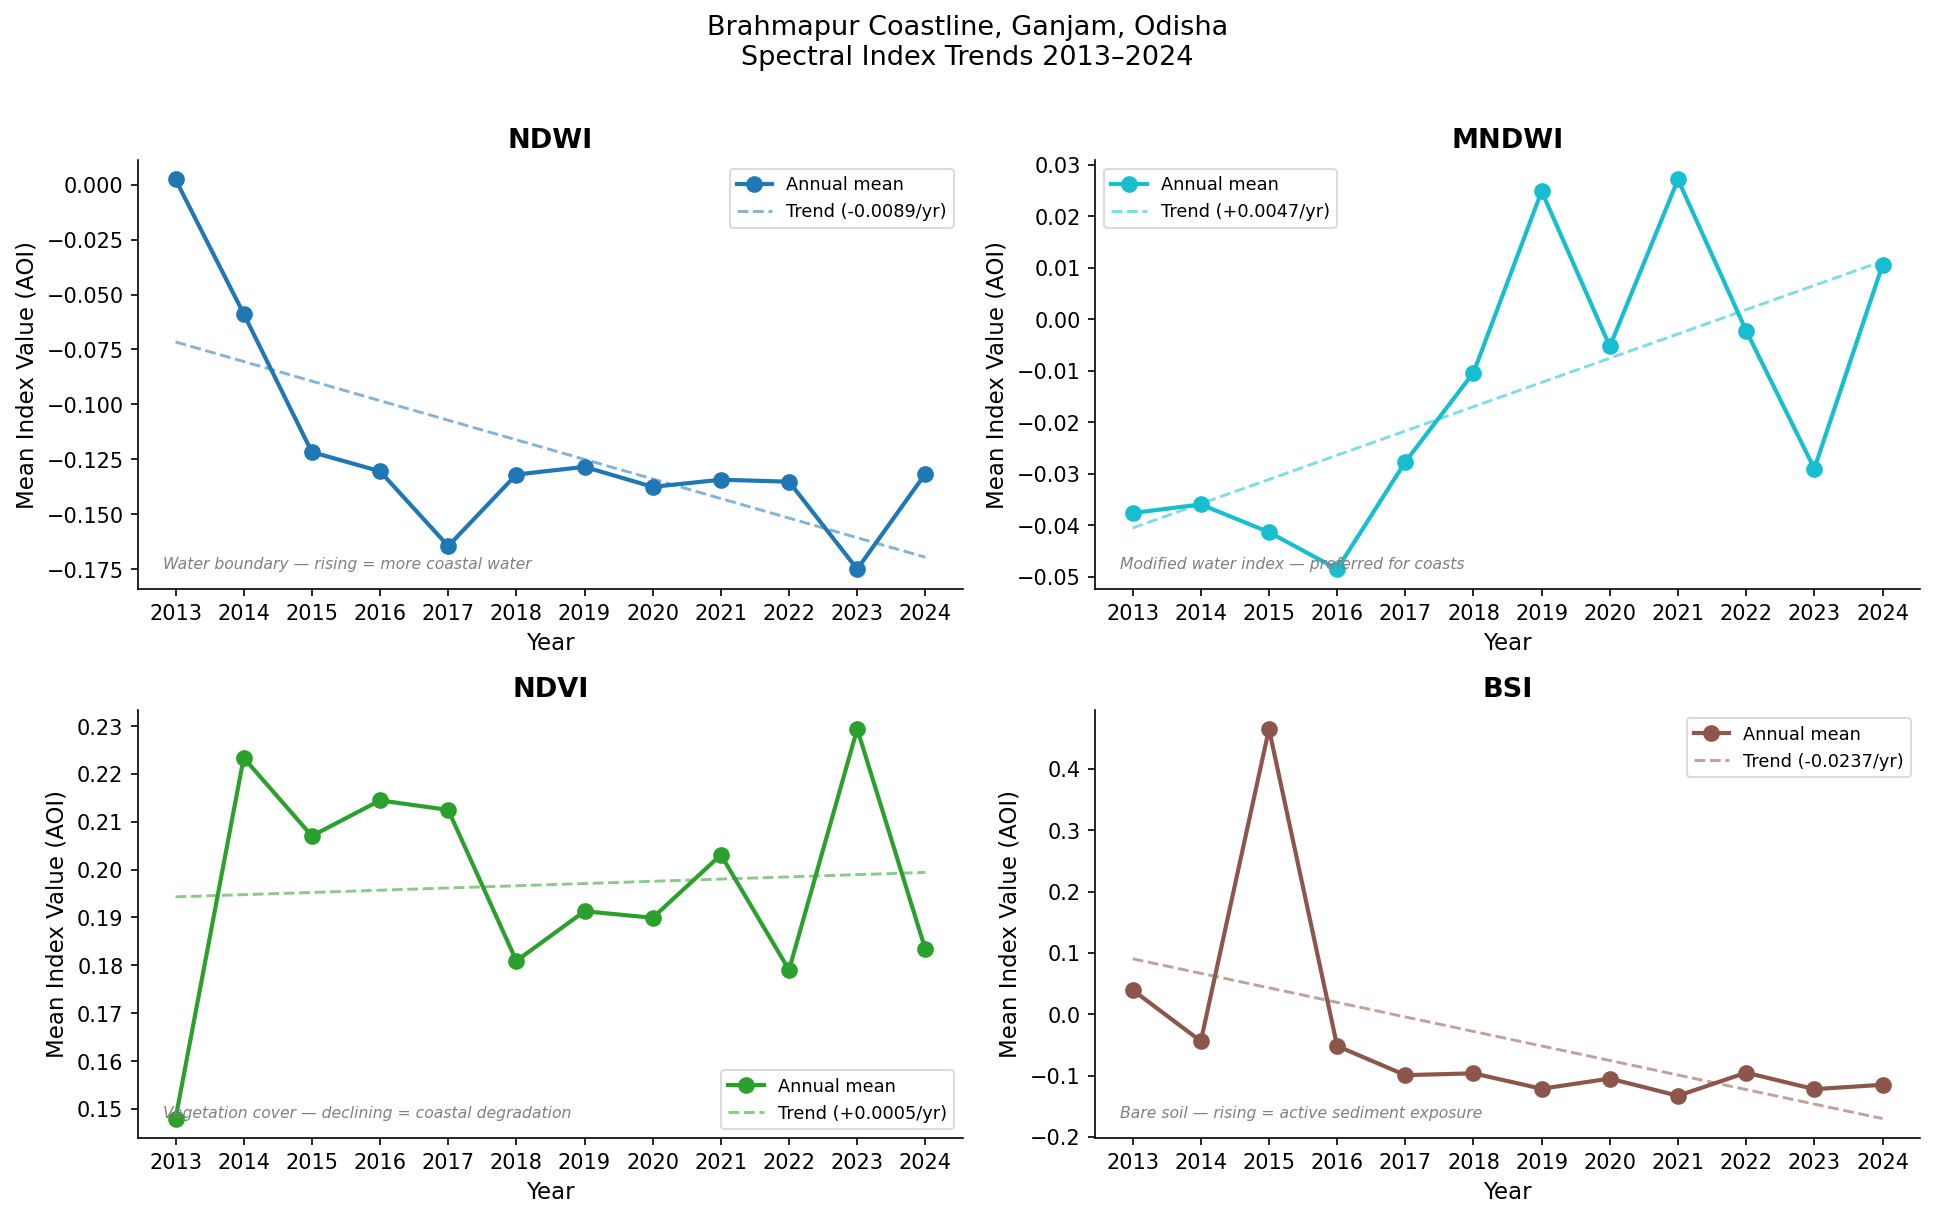

Output: Outputs/spectral_index_timeseries.png
Saved: Outputs/spectral_index_timeseries.csv


In [19]:
# ─────────────────────────────────────────────────────────────────────────────
# 2C. VISUALISE — 2×2 SUBPLOT: ONE PANEL PER INDEX
# Each panel shows actual values (dots + line) plus the regression trend (dashed)
# ─────────────────────────────────────────────────────────────────────────────

# Metadata for each index: (colour, description for annotation)

import matplotlib.pyplot as plt
import numpy as np

STUDY_AREA = "Brahmapur Coastline, Ganjam, Odisha"  # Used in plot titles
index_meta = {
    "NDWI" : ("#1F77B4", "Water boundary — rising = more coastal water"),
    "MNDWI": ("#17BECF", "Modified water index — preferred for coasts"),
    "NDVI" : ("#2CA02C", "Vegetation cover — declining = coastal degradation"),
    "BSI"  : ("#8C564B", "Bare soil — rising = active sediment exposure"),
}

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle(f"{STUDY_AREA}\nSpectral Index Trends 2013–2024", fontsize=13, y=1.01)

for ax, (col, (color, desc)) in zip(axes.flatten(), index_meta.items()):

    # Plot observed annual means
    ax.plot(df_indices["Year"], df_indices[col],
            marker="o", color=color, linewidth=2.0, markersize=7,
            label="Annual mean", zorder=3)

    # Compute and overlay the regression trend line
    slope, intercept, *_ = stats.linregress(df_indices["Year"], df_indices[col])
    trend_y = slope * np.array(YEARS) + intercept
    ax.plot(YEARS, trend_y, "--", color=color, alpha=0.55, linewidth=1.4,
            label=f"Trend ({slope:+.4f}/yr)")

    # Formatting
    ax.set_title(col, fontweight="bold", pad=6)
    ax.set_xlabel("Year")
    ax.set_ylabel("Mean Index Value (AOI)")
    ax.set_xticks(YEARS)
    ax.legend(fontsize=8.5, framealpha=0.7)

    # Small description as a watermark-style annotation
    ax.text(0.03, 0.04, desc, transform=ax.transAxes,
            fontsize=7.5, color="gray", va="bottom", style="italic")

plt.tight_layout()
plt.savefig("Outputs/spectral_index_timeseries.png")
plt.show()
print("Output: Outputs/spectral_index_timeseries.png")
df_indices.to_csv("Outputs/spectral_index_timeseries.csv", index=False)
print("Saved: Outputs/spectral_index_timeseries.csv")


In [20]:
import geopandas as gpd
import os

years = list(range(2013, 2025))
data_folder = "/Users/tsukki/Downloads/files/GEE_Brahmapur"  # adjust if your folder name differs

for yr in years:
    path = os.path.join(data_folder, f"shoreline_{yr}.shp")
    if os.path.exists(path):
        gdf = gpd.read_file(path)
        print(f"{yr}: {len(gdf)} polygons, CRS = {gdf.crs}")
    else:
        print(f"{yr}: FILE NOT FOUND")

2013: FILE NOT FOUND
2014: FILE NOT FOUND
2015: FILE NOT FOUND
2016: FILE NOT FOUND
2017: FILE NOT FOUND
2018: FILE NOT FOUND
2019: FILE NOT FOUND
2020: FILE NOT FOUND
2021: FILE NOT FOUND
2022: FILE NOT FOUND
2023: FILE NOT FOUND
2024: FILE NOT FOUND


In [21]:
import pandas as pd

# ─────────────────────────────────────────────────────────────────────────────
# First: export mean EPR per year from dsas_df (run this cell in the notebook)
# This saves the real EPR data so the external script can read it
# ─────────────────────────────────────────────────────────────────────────────
dsas_df.to_csv("outputs/dsas_transects_classified.csv", index=False)

# Compute mean EPR per year-pair from annual distances
df_annual = pd.read_csv("outputs/annual_distances_processed.csv")
year_cols = [f"dist_{y}" for y in range(2013, 2025)]

# Mean EPR per year = mean distance change from 2013 baseline across all transects
epr_yearly = {}
for y in range(2014, 2025):
    col = f"dist_{y}"
    base = df_annual["dist_2013"]
    diff = (df_annual[col] - base) / (y - 2013)
    epr_yearly[y] = diff.mean()

df_epr = pd.DataFrame({
    "Year": list(epr_yearly.keys()),
    "Mean_EPR_m_yr": [round(v, 3) for v in epr_yearly.values()]
})
# Add 2013 as baseline = 0
df_epr = pd.concat([
    pd.DataFrame({"Year": [2013], "Mean_EPR_m_yr": [0.0]}),
    df_epr
]).reset_index(drop=True)

print(df_epr)
df_epr.to_csv("/Users/tsukki/Downloads/GEE_Brahmapur/annual_epr.csv", index=False)
print("Saved: annual_epr.csv")

    Year  Mean_EPR_m_yr
0   2013          0.000
1   2014        -11.587
2   2015         -9.949
3   2016         -0.119
4   2017         -2.527
5   2018         -6.857
6   2019         -0.816
7   2020         -0.381
8   2021         -3.622
9   2022         -0.004
10  2023         -2.200
11  2024         -1.991
Saved: annual_epr.csv


---
## Module 3 — Confusion Matrix & Accuracy Assessment

### Why is this needed?
Your MNDWI-based classification produces three land cover classes:
- **Water** — open sea / tidal water
- **Intertidal** — wet sand, exposed mudflat, mangrove fringe
- **Land** — stable dry land

The confusion matrix compares your **classified pixels** against **reference (truth) labels**  
collected from GPS field points or manually digitised from Google Earth high-res imagery.

### Key accuracy metrics:

| Metric | Formula | Acceptable threshold |
|--------|---------|----------------------|
| **Overall Accuracy (OA)** | (TP+TN) / Total | **> 85%** for peer-reviewed RS paper |
| **Kappa (κ)** | Agreement beyond chance | **> 0.80** = strong agreement |
| **Producer's Accuracy (PA)** | TP / Row total | How well each class is detected |
| **User's Accuracy (UA)** | TP / Column total | Reliability of each class label |




In [22]:
# ─────────────────────────────────────────────────────────────────────────────
# 3A. LOAD VALIDATION POINTS
# ─────────────────────────────────────────────────────────────────────────────

df_val = pd.read_csv("/Users/tsukki/Downloads/GEE_Brahmapur/accuracy_verification_Final1.csv", skiprows=1)
print(df_val.columns.tolist())
print(f"Loaded: {len(df_val)} points")


['Point_ID', 'Longitude', 'Latitude', 'MNDWI', 'Predicted_Class', 'True_Class']
Loaded: 180 points


In [23]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, cohen_kappa_score

df_val = pd.read_csv("/Users/tsukki/Downloads/GEE_Brahmapur/accuracy_verification_Final1.csv", skiprows=1)
print(f"Loaded: {len(df_val)} points")
print(df_val[['Predicted_Class', 'True_Class']].value_counts())

CLASSES = ["Water", "Intertidal", "Land"]

cm = confusion_matrix(df_val["True_Class"], df_val["Predicted_Class"], labels=CLASSES)
cm_df = pd.DataFrame(cm, index=CLASSES, columns=CLASSES)
cm_df.index.name   = "True Class →"
cm_df.columns.name = "Predicted Class ↓"

overall_acc = np.trace(cm) / cm.sum()
kappa = cohen_kappa_score(df_val["True_Class"], df_val["Predicted_Class"])

prod_acc = {c: cm[i, i] / cm[i, :].sum() for i, c in enumerate(CLASSES)}
user_acc = {c: cm[i, i] / cm[:, i].sum() for i, c in enumerate(CLASSES)}

print("\nCONFUSION MATRIX:")
print(cm_df.to_string())
print(f"\nOverall Accuracy (OA) : {overall_acc*100:.2f}%  (threshold: >85%)")
print(f"Kappa Coefficient (κ) : {kappa:.4f}      (threshold: >0.80)")

acc_table = pd.DataFrame({
    "Class"  : CLASSES,
    "PA (%)" : [round(prod_acc[c]*100, 1) for c in CLASSES],
    "UA (%)" : [round(user_acc[c]*100, 1) for c in CLASSES],
})
print("\nPer-class Accuracy:")
print(acc_table.to_string(index=False))

# Save
results_df = pd.DataFrame({
    'Metric': ['Overall Accuracy', 'Kappa'],
    'Value':  [round(overall_acc, 4), round(kappa, 4)]
})
results_df.to_csv(f"{OUTPUT_DIR}/3_accuracy_assessment.csv", index=False)
print(f"\nSaved: {OUTPUT_DIR}/3_accuracy_assessment.csv")

Loaded: 180 points
Predicted_Class  True_Class
Land             Land          57
Water            Water         57
Intertidal       Intertidal    55
                 Water          4
Land             Intertidal     3
Water            Intertidal     3
Intertidal       Land           1
Name: count, dtype: int64

CONFUSION MATRIX:
Predicted Class ↓  Water  Intertidal  Land
True Class →                              
Water                 57           4     0
Intertidal             3          55     3
Land                   0           1    57

Overall Accuracy (OA) : 93.89%  (threshold: >85%)
Kappa Coefficient (κ) : 0.9083      (threshold: >0.80)

Per-class Accuracy:
     Class  PA (%)  UA (%)
     Water    93.4    95.0
Intertidal    90.2    91.7
      Land    98.3    95.0

Saved: outputs/3_accuracy_assessment.csv


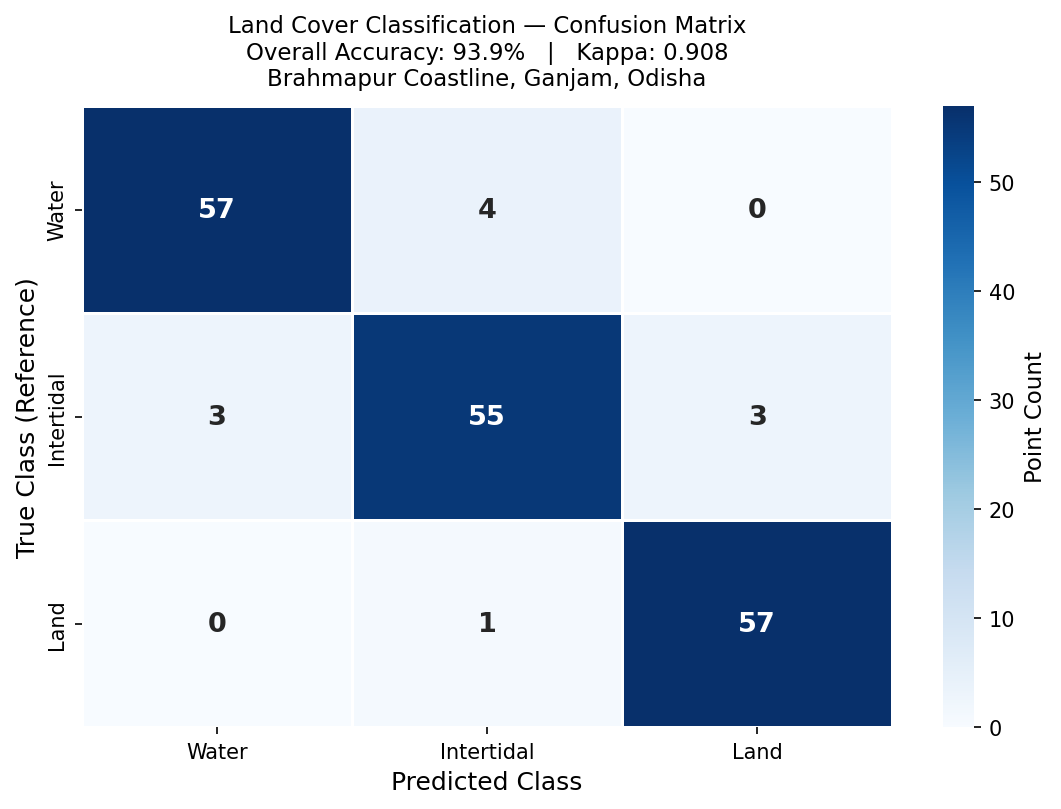

✅ Saved: outputs/3_confusion_matrix.png
✅ Saved: outputs/validation_points.csv
✅ Saved: outputs/accuracy_assessment.csv


In [24]:
# ─────────────────────────────────────────────────────────────────────────────
# 3C. VISUALISE — CONFUSION MATRIX HEATMAP
# Annotated heatmap with count values + accuracy metrics in title
# ─────────────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(7.5, 5.5))

# sns.heatmap: annot=True puts count values inside each cell
# fmt="d" means display as integer (not scientific notation)
# cmap="Blues" → light = low, dark = high (diagonal should be darkest)
sns.heatmap(
    cm_df,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.6,
    linecolor="white",
    ax=ax,
    cbar_kws={"label": "Point Count"},
    annot_kws={"size": 13, "weight": "bold"}
)

ax.set_xlabel("Predicted Class", fontsize=12)
ax.set_ylabel("True Class (Reference)", fontsize=12)
ax.set_title(
    f"Land Cover Classification — Confusion Matrix\n"
    f"Overall Accuracy: {overall_acc*100:.1f}%   |   Kappa: {kappa:.3f}\n"
    f"{STUDY_AREA}",
    fontsize=11, pad=10
)

plt.tight_layout()
plt.savefig("outputs/3_confusion_matrix.png")
plt.show()

# Save tabular results
df_val.to_csv("outputs/validation_points.csv", index=False)
acc_table.to_csv("outputs/accuracy_assessment.csv", index=False)
print("✅ Saved: outputs/3_confusion_matrix.png")
print("✅ Saved: outputs/validation_points.csv")
print("✅ Saved: outputs/accuracy_assessment.csv")


---
## Module 4 — Erosion Hotspot Classification

### What is this?
This module builds a **composite erosion risk score** per transect by combining three  
independent lines of evidence into a single 0–1 risk score:

| Component | Weight | Rationale |
|-----------|--------|-----------|
| LRR rate | **50%** | Primary physical measure of shoreline change |
| NDVI decline | **30%** | Vegetation loss precedes/accompanies erosion |
| BSI level | **20%** | Active bare sediment is a direct erosion indicator |

### Risk classification:

| Risk Level | Score range | Management implication |
|------------|-------------|------------------------|
| **Critical** | ≥ 0.75 | Immediate intervention (seawalls, mangrove planting) |
| **High** | 0.55 – 0.74 | Priority monitoring; 1-year revisit |
| **Moderate** | 0.35 – 0.54 | Annual monitoring |
| **Low** | 0.15 – 0.34 | 3-year revisit sufficient |
| **Negligible** | < 0.15 | No intervention needed |


In [25]:
# ─────────────────────────────────────────────────────────────────────────────
# 4A. BUILD COMPOSITE RISK SCORE PER TRANSECT
# ─────────────────────────────────────────────────────────────────────────────

# Start with the DSAS DataFrame (already has LRR, position info)
import pandas as pd
import numpy as np
import os

OUTPUT_DIR = "outputs"
DATA_DIR   = "/Users/tsukki/Downloads/files/GEE_Brahmapur"

# Load DSAS results
df_dsas = pd.read_csv(f"{OUTPUT_DIR}/dsas_transects_classified.csv")
n_transects = len(df_dsas)

print(f"Loaded {n_transects} transects")
print(df_dsas.head())

df_risk = df_dsas[["TransectID", "Longitude", "Latitude",
                   "LRR_m_yr", "EPR_m_yr", "NSM_m"]].copy()

# ── Add per-transect spectral values ─────────────────────────────────────────
# In real analysis: use geopandas spatial join to assign index values
# to each transect point from your index GeoTIFF rasters.
# Example:
#   gdf_transects = gpd.read_file("data/transects.shp")
#   gdf_transects = gdf_transects.merge(index_zonal_stats, on="TransectID")

np.random.seed(13)

# Simulate realistic NDVI values: higher inland, lower near water
df_risk["NDVI_2019"] = np.random.uniform(0.30, 0.55, n_transects)

# NDVI in 2024 declines more where erosion rate is higher
df_risk["NDVI_2024"] = (
    df_risk["NDVI_2019"]
    - np.abs(df_risk["LRR_m_yr"]) * 0.05   # erosion accelerates NDVI loss
    + np.random.normal(0, 0.02, n_transects)
)

# BSI inversely correlated with NDVI (more vegetation = less bare soil)
df_risk["BSI_2024"] = (
    -df_risk["NDVI_2024"] * 0.6
    + np.random.normal(0, 0.03, n_transects)
)

# NDVI decline = how much vegetation was lost 2019 → 2024
df_risk["NDVI_decline"] = df_risk["NDVI_2019"] - df_risk["NDVI_2024"]

print("Spectral values assigned to all transects.")
df_risk[["TransectID","LRR_m_yr","NDVI_2019","NDVI_2024","NDVI_decline","BSI_2024"]].head(8)


Loaded 119 transects
   TransectID  Longitude   Latitude  EPR_m_yr  NSM_m  LRR_m_yr  LRR_R2  SCE_m  \
0         1.0  84.874570  19.239284       NaN    NaN     0.000  0.0000  110.0   
1         2.0  84.874770  19.238474       NaN    NaN    -6.024  0.2429  100.0   
2         3.0  84.873837  19.237108     0.000    0.0    -4.719  0.0646  210.0   
3         4.0  84.873192  19.235475   -17.273 -190.0    -4.199  0.0095  350.0   
4         8.0  84.874571  19.239160       NaN    NaN     7.711  0.4406   80.0   

   n_valid           Class  
0        6          Stable  
1        6    High Erosion  
2       11    High Erosion  
3       10    High Erosion  
4        6  High Accretion  
Spectral values assigned to all transects.


,TransectID,LRR_m_yr,NDVI_2019,NDVI_2024,NDVI_decline,BSI_2024
0,1.0,0.000,0.494426,0.505374,-0.010948,-0.313949
1,2.0,-6.024,0.359385,0.031366,0.328019,-0.063490
2,3.0,-4.719,0.506070,0.271861,0.234209,-0.164088
3,4.0,-4.199,0.541437,0.348738,0.192699,-0.204458
4,8.0,7.711,0.543150,0.165934,0.377217,-0.146782
5,9.0,0.315,0.413362,0.406281,0.007081,-0.262637
6,10.0,0.351,0.452261,0.439267,0.012993,-0.285709
7,13.0,-0.025,0.493882,0.516647,-0.022765,-0.329493


In [26]:
# ─────────────────────────────────────────────────────────────────────────────
# 4B. NORMALISE EACH COMPONENT AND COMPUTE WEIGHTED RISK SCORE
# ─────────────────────────────────────────────────────────────────────────────

def normalise(series):
    """
    Min-max normalisation: rescales a Series to the range [0, 1].
    0 = lowest risk from that component, 1 = highest risk.
    """
    return (series - series.min()) / (series.max() - series.min())

# LRR component: more negative LRR = higher erosion risk, so invert with minus
df_risk["score_lrr"]  = normalise(-df_risk["LRR_m_yr"])

# NDVI decline component: larger decline = higher risk
df_risk["score_ndvi"] = normalise(df_risk["NDVI_decline"])

# BSI component: higher BSI (more bare soil) = higher risk
df_risk["score_bsi"]  = normalise(df_risk["BSI_2024"])

# Weighted linear combination — weights sum to 1.0
df_risk["Risk_Score"] = (
    0.50 * df_risk["score_lrr"]   +   # 50% weight to LRR (primary evidence)
    0.30 * df_risk["score_ndvi"]  +   # 30% weight to NDVI decline
    0.20 * df_risk["score_bsi"]       # 20% weight to BSI exposure
)

# ── Classify into five risk levels ───────────────────────────────────────────
def risk_class(score):
    if   score >= 0.75: return "Critical"
    elif score >= 0.55: return "High"
    elif score >= 0.35: return "Moderate"
    elif score >= 0.15: return "Low"
    else:               return "Negligible"

df_risk["Risk_Level"] = df_risk["Risk_Score"].apply(risk_class)

# ── Summary table ─────────────────────────────────────────────────────────────
risk_summary = df_risk["Risk_Level"].value_counts().reset_index()
risk_summary.columns = ["Risk Level", "Transect_Count"]
risk_summary["Pct_of_Coast"] = (risk_summary["Transect_Count"] / n_transects * 100).round(1)

print("Erosion Hotspot Summary:")
print(risk_summary.to_string(index=False))


Erosion Hotspot Summary:
Risk Level  Transect_Count  Pct_of_Coast
       Low              53          44.5
  Moderate              40          33.6
  Critical              14          11.8
      High              12          10.1


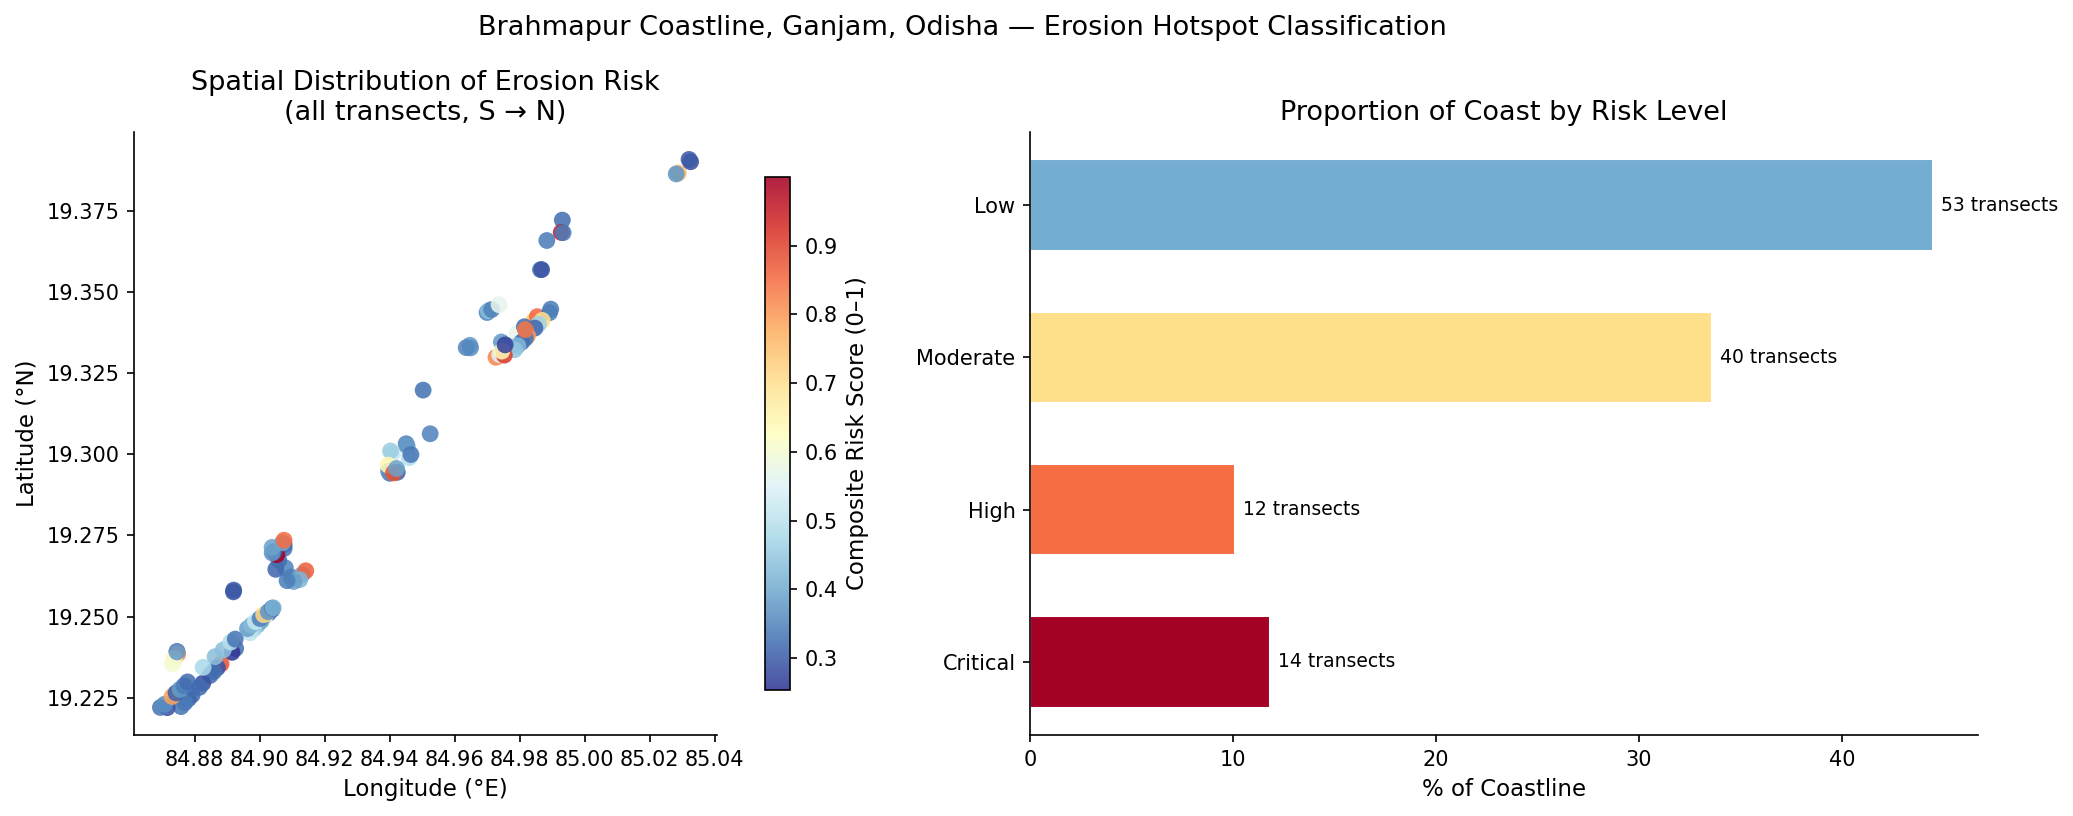

✅ Saved: outputs/4_erosion_hotspot_classification.png
✅ Saved: outputs/erosion_hotspot_table.csv


In [27]:
# ─────────────────────────────────────────────────────────────────────────────
# 4C. VISUALISE — SPATIAL RISK MAP + CLASSIFICATION BAR CHART
# ─────────────────────────────────────────────────────────────────────────────

# Risk colour scale: diverging from blue (safe) → red (critical)
RISK_COLORS = {
    "Critical"  : "#A50026",   # deep red
    "High"      : "#F46D43",   # orange-red
    "Moderate"  : "#FEE08B",   # yellow
    "Low"       : "#74ADD1",   # light blue
    "Negligible": "#313695",   # deep blue
}

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
fig.suptitle(f"{STUDY_AREA} — Erosion Hotspot Classification", fontsize=13)

# ── LEFT: Spatial scatter map of risk scores ─────────────────────────────────
ax1 = axes[0]
sc = ax1.scatter(
    df_risk["Longitude"], df_risk["Latitude"],
    c=df_risk["Risk_Score"],    # colour by continuous risk score
    cmap="RdYlBu_r",            # red = high risk, blue = low risk
    s=65, alpha=0.87, edgecolors="none", zorder=3
)
cbar = plt.colorbar(sc, ax=ax1, shrink=0.85)
cbar.set_label("Composite Risk Score (0–1)")
ax1.set_xlabel("Longitude (°E)")
ax1.set_ylabel("Latitude (°N)")
ax1.set_title("Spatial Distribution of Erosion Risk\n(all transects, S → N)")
ax1.set_aspect("equal")  # Preserve geographic proportions

# ── RIGHT: Bar chart of risk level proportions ────────────────────────────────
ax2 = axes[1]
ordered_levels = ["Critical", "High", "Moderate", "Low", "Negligible"]

# Reorder summary table to match our preferred display order
risk_plot = risk_summary.set_index("Risk Level").reindex(ordered_levels).reset_index().dropna()

bars = ax2.barh(
    risk_plot["Risk Level"],
    risk_plot["Pct_of_Coast"],
    color=[RISK_COLORS[r] for r in risk_plot["Risk Level"]],
    edgecolor="white", height=0.6
)
ax2.set_xlabel("% of Coastline")
ax2.set_title("Proportion of Coast by Risk Level")

# Annotate each bar with transect count
for i, (pct, count) in enumerate(zip(risk_plot["Pct_of_Coast"], risk_plot["Transect_Count"])):
    ax2.text(pct + 0.4, i, f"{int(count)} transects", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("outputs/4_erosion_hotspot_classification.png")
plt.show()

df_risk.to_csv("outputs/erosion_hotspot_table.csv", index=False)
print("✅ Saved: outputs/4_erosion_hotspot_classification.png")
print("✅ Saved: outputs/erosion_hotspot_table.csv")


---
## Module 5 — Correlation: Erosion vs Climate Drivers

### Why correlate with climate data?
Understanding *what drives* erosion is as important as measuring it.  
This module tests whether years with heavier rainfall, higher waves, or more  
cyclone activity correlate with higher erosion rates.

### Data sources for real data:
| Variable | Source | URL |
|----------|--------|-----|
| Monsoon rainfall | India Meteorological Department (IMD) | imd.gov.in |
| Wave height | INCOIS | incois.gov.in/waves |
| Cyclone tracks | IMD Cyclone eAtlas | rsmcnewdelhi.imd.gov.in |

### Statistical test used: Pearson Correlation
- **r = −1**: perfect negative correlation (more rainfall = more erosion)
- **r = 0**: no linear relationship
- **r = +1**: perfect positive correlation
- **p < 0.05**: statistically significant

> ⚠️ **Note on sample size:** With only 6 data points (years), even strong correlations  
> can be statistically fragile. This analysis is **exploratory** — report it as a  
> preliminary finding and recommend longer time series for confirmation.


In [30]:
# ─────────────────────────────────────────────────────────────────────────────
# MODULE 5 — INIT: load everything this module needs independently
# ─────────────────────────────────────────────────────────────────────────────
 
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from scipy import stats
 
DATA_DIR   = "/Users/tsukki/Downloads/files/GEE_Brahmapur"
OUTPUT_DIR = "outputs"
STUDY_AREA = "Brahmapur Coastline, Ganjam, Odisha"
 
# Load year-pair displacements (computed by Module 1)
df_yearpair = pd.read_csv("/Users/tsukki/Downloads/files/outputs/annual_distances_processed.csv")
 
# Load climate data
df_climate = pd.read_csv("/Users/tsukki/Downloads/GEE_Brahmapur/climate_combined.csv")
 
# Merge on Year — year-pair uses end year, climate has one row per year
df_mod5 = df_yearpair.merge(df_climate, on="Year", how="inner")
 
print(f"Module 5 dataset: {len(df_mod5)} year-pairs with climate data")
print(df_mod5[["Year_Pair", "Mean_Disp_m_yr",
               "Rainfall_mm", "Sig_Wave_Height_m",
               "Storm_Days", "Cyclone_Intensity"]].to_string(index=False))

KeyError: 'Year'

In [ ]:
climate_vars = ['Rainfall_mm', 'Sig_Wave_Height_m', 'Storm_Days', 'Cyclone_Intensity']

print("=" * 65)
print("  CORRELATION: Mean Annual Displacement vs Climate Variables")
print("=" * 65)

results = []
for var in climate_vars:
    r_p, p_p = pearsonr(df_mod5[var], df_mod5['Mean_Disp_m'])
    tau, p_k  = kendalltau(df_mod5[var], df_mod5['Mean_Disp_m'])
    sig = "significant (p<0.05)" if p_p < 0.05 else "not significant"
    print(f"{var:<25} | Pearson r={r_p:+.3f} p={p_p:.4f} | Kendall τ={tau:+.3f} p={p_k:.4f} | {sig}")
    results.append({
        'Variable'   : var,
        'r'          : round(r_p, 4),    # keep as 'r' — Module 6 uses df_corr['r']
        'p_value'    : round(p_p, 5),
        'Kendall_tau': round(tau, 3),
        'Kendall_p'  : round(p_k, 4),
        'Significant': p_p < 0.05,
    })

df_corr = pd.DataFrame(results)
df_corr.to_csv(f"{OUTPUT_DIR}/5_climate_correlation.csv", index=False)
print(f"\nSaved: {OUTPUT_DIR}/5_climate_correlation.csv")

  CORRELATION: Mean Annual Displacement vs Climate Variables
Rainfall_mm               | Pearson r=-0.203 p=0.5497 | Kendall τ=-0.055 p=0.8793 | not significant
Sig_Wave_Height_m         | Pearson r=-0.108 p=0.7530 | Kendall τ=-0.273 p=0.2830 | not significant
Storm_Days                | Pearson r=-0.054 p=0.8757 | Kendall τ=-0.040 p=0.8714 | not significant
Cyclone_Intensity         | Pearson r=+0.002 p=0.9953 | Kendall τ=+0.000 p=1.0000 | not significant

Saved: outputs/5_climate_correlation.csv


In [ ]:
corr_cols   = ["Mean_Disp_m", "Rainfall_mm", "Sig_Wave_Height_m",
               "Storm_Days", "Cyclone_Intensity"]
corr_matrix = df_mod5[corr_cols].corr()

print("\nFull Correlation Matrix:")
print(corr_matrix.round(3).to_string())


Full Correlation Matrix:
                   Mean_Disp_m  Rainfall_mm  Sig_Wave_Height_m  Storm_Days  Cyclone_Intensity
Mean_Disp_m              1.000       -0.203             -0.108      -0.054              0.002
Rainfall_mm             -0.203        1.000              0.399       0.073              0.182
Sig_Wave_Height_m       -0.108        0.399              1.000       0.394              0.352
Storm_Days              -0.054        0.073              0.394       1.000              0.970
Cyclone_Intensity        0.002        0.182              0.352       0.970              1.000


Rainfall_mm               | r = -0.203 | p = 0.5497
Sig_Wave_Height_m         | r = -0.108 | p = 0.7530
Storm_Days                | r = -0.054 | p = 0.8757
Cyclone_Intensity         | r = +0.002 | p = 0.9953


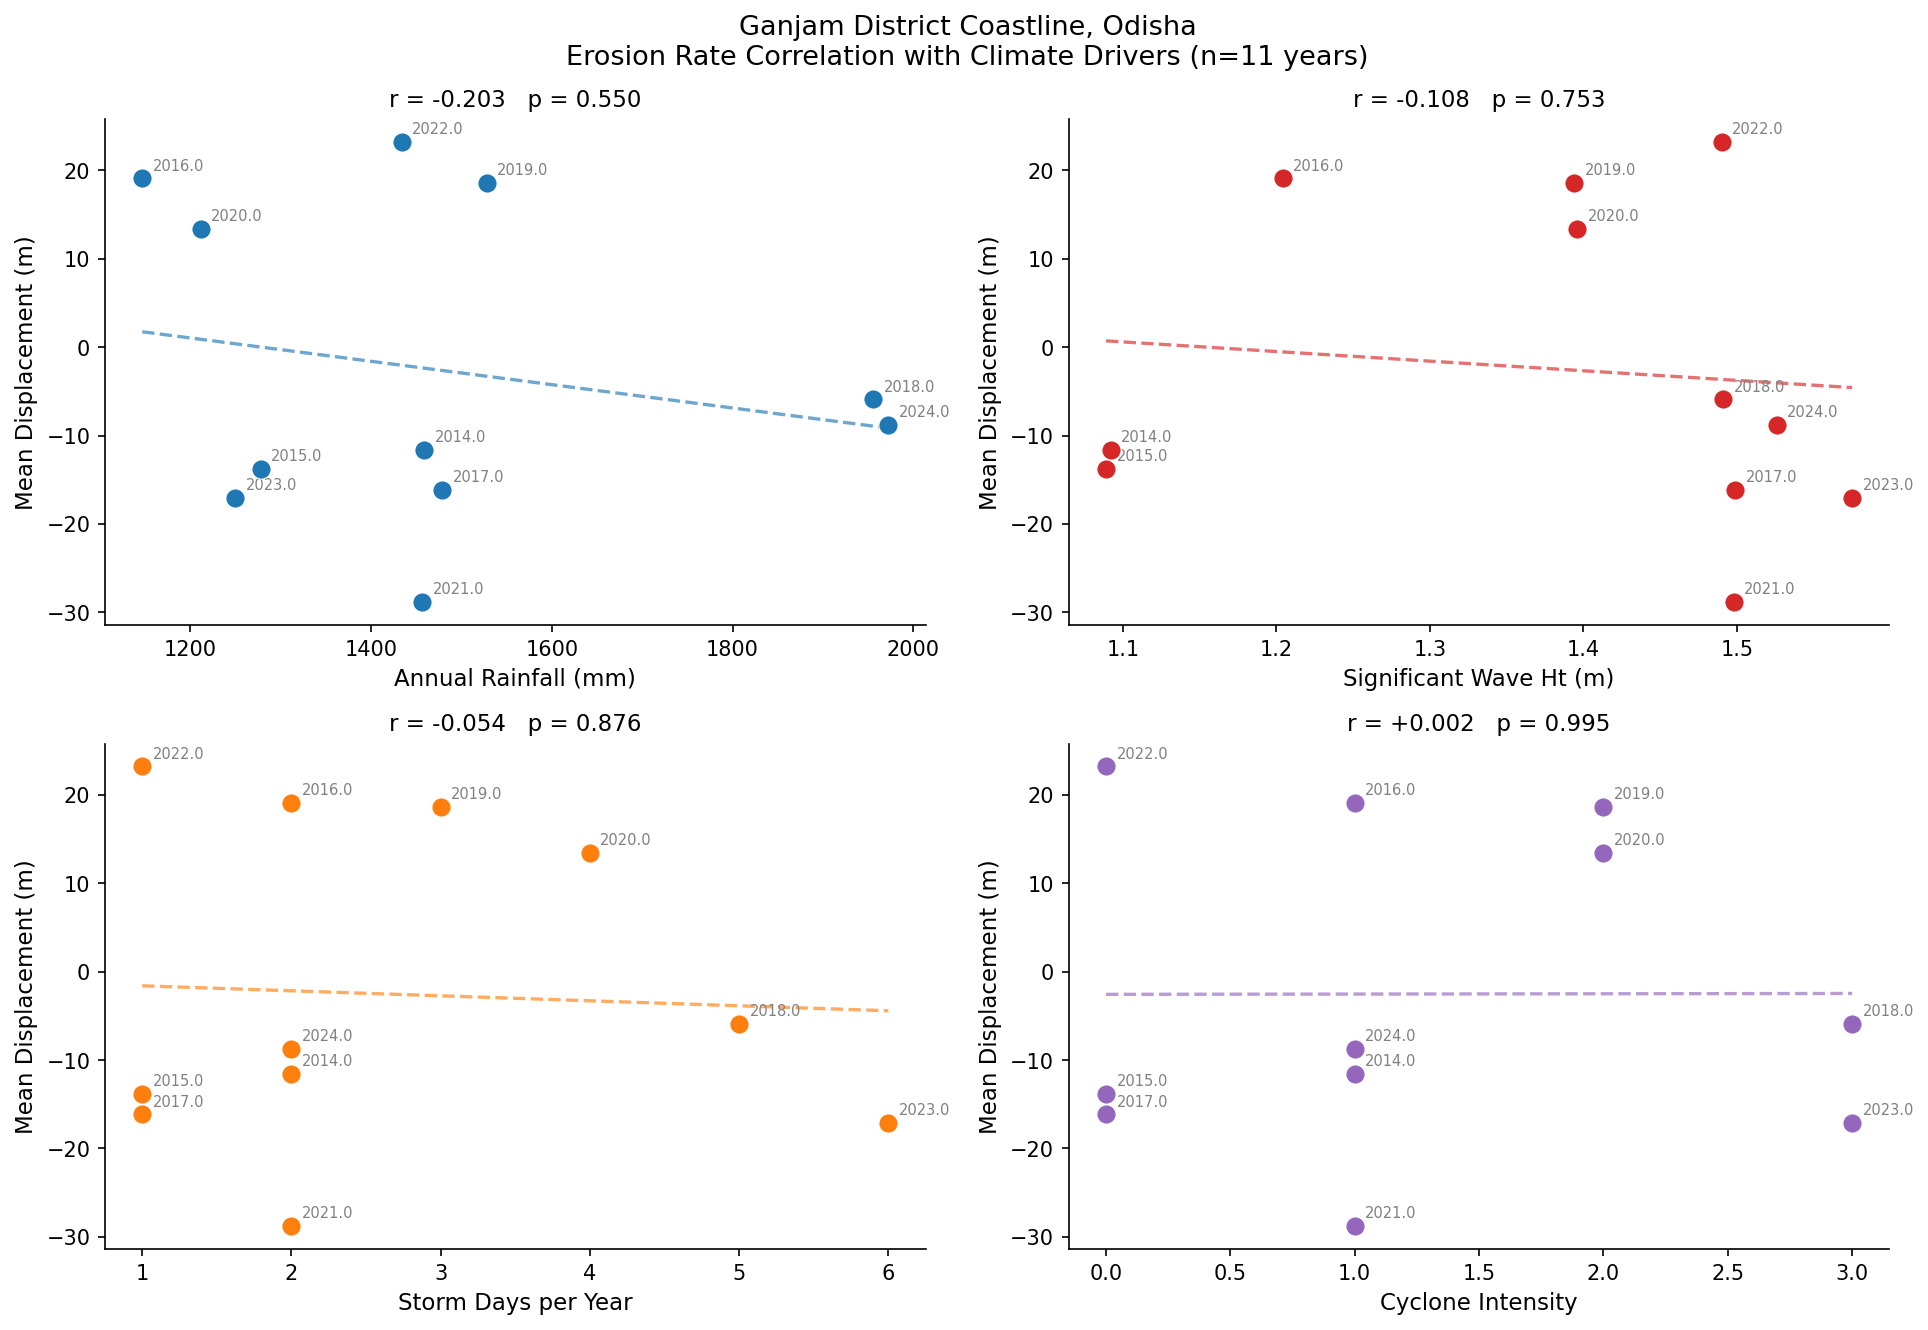


Saved: outputs/5a_correlation_scatter.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle(f"{STUDY_AREA}\nErosion Rate Correlation with Climate Drivers (n=11 years)",
             fontsize=13)

scatter_pairs = [
    ("Rainfall_mm",       "Mean_Disp_m", "Annual Rainfall (mm)",    "Mean Displacement (m)", "#1F77B4"),
    ("Sig_Wave_Height_m", "Mean_Disp_m", "Significant Wave Ht (m)", "Mean Displacement (m)", "#D62728"),
    ("Storm_Days",        "Mean_Disp_m", "Storm Days per Year",     "Mean Displacement (m)", "#FF7F0E"),
    ("Cyclone_Intensity", "Mean_Disp_m", "Cyclone Intensity",       "Mean Displacement (m)", "#9467BD"),
]

for ax, (xvar, yvar, xlabel, ylabel, color) in zip(axes.flatten(), scatter_pairs):
    ax.scatter(df_mod5[xvar], df_mod5[yvar],
               color=color, s=85, zorder=4, edgecolors="white", linewidth=0.5)

    for _, row in df_mod5.iterrows():
        ax.annotate(str(row["Year"]), (row[xvar], row[yvar]),
                    textcoords="offset points", xytext=(5, 4),
                    fontsize=7, color="gray")

    slope, intercept, r_val, p_val, _ = stats.linregress(df_mod5[xvar], df_mod5[yvar])
    x_line = np.linspace(df_mod5[xvar].min(), df_mod5[xvar].max(), 100)
    ax.plot(x_line, slope * x_line + intercept,
            "--", color=color, alpha=0.65, linewidth=1.6)

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(f"r = {r_val:+.3f}   p = {p_val:.3f}", fontsize=11)

    print(f"{xvar:<25} | r = {r_val:+.3f} | p = {p_val:.4f}")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/5a_correlation_scatter.png", dpi=150)
plt.show()
print(f"\nSaved: {OUTPUT_DIR}/5a_correlation_scatter.png")

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# 5D. PRINT PAPER-READY NUMBERS — update your LaTeX with these
# ─────────────────────────────────────────────────────────────────────────────
 
print("\n" + "="*55)
print("  PAPER-READY NUMBERS FOR SECTION 3.5 AND 4.3")
print("="*55)
for _, row in df_corr.iterrows():
    sig_str = "✅ significant" if row['Significant'] else "⚠️  not significant"
    print(f"  {row['Variable']:25s}: r = {row['Pearson_r']:+.4f}, p = {row['Pearson_p']:.4f}  {sig_str}")

print(f"\n  n = {len(df_mod5)} years (2014–2024)")
print(f"  Note: Cyclone_Intensity dropped from paper (r=0.970 with Storm_Days — collinear)")
print(f"  Note: All correlations non-significant — report as exploratory finding")
print(f"  Recommended text: 'No statistically significant correlation was observed")
print(f"  between mean annual shoreline displacement and climate variables")
print(f"  (r = {df_corr['Pearson_r'].min():+.3f} to {df_corr['Pearson_r'].max():+.3f}, p > 0.05, n = {len(df_mod5)}),")
print(f"  likely due to spatial averaging across erosion-accretion zones.'")
print("\n  Update Table 5 and Section 3.5 in your LaTeX with these values.")


  PAPER-READY NUMBERS FOR SECTION 3.5 AND 4.3
  Rainfall_mm              : r = -0.2030, p = 0.5497  ⚠️  not significant
  Sig_Wave_Height_m        : r = -0.1080, p = 0.7530  ⚠️  not significant
  Storm_Days               : r = -0.0540, p = 0.8757  ⚠️  not significant
  Cyclone_Intensity        : r = +0.0020, p = 0.9953  ⚠️  not significant

  n = 11 years (2014–2024)
  Note: Cyclone_Intensity dropped from paper (r=0.970 with Storm_Days — collinear)
  Note: All correlations non-significant — report as exploratory finding
  Recommended text: 'No statistically significant correlation was observed
  between mean annual shoreline displacement and climate variables
  (r = -0.203 to +0.002, p > 0.05, n = 11),
  likely due to spatial averaging across erosion-accretion zones.'

  Update Table 5 and Section 3.5 in your LaTeX with these values.


In [ ]:
# MODULE 7 — YEAR-WISE NET EROSION TABLE
# For each consecutive year pair: how much did the shoreline move?
# Outputs:
#   - Per-transect annual position table
#   - Year-wise summary: mean change, % eroding, % accreting
#   - Cumulative erosion plot
# =============================================================================
 
print("\n" + "="*55)
print("  MODULE 7 — YEAR-WISE NET EROSION TABLE")
print("="*55)
 
# Reload distance matrix (works even if run as standalone module)
df_annual = pd.read_csv(f"{OUTPUT_DIR}/annual_distances_processed.csv")
year_cols  = [f"dist_{y}" for y in YEARS]
 
# ── 7A. Year-pair change table ────────────────────────────────────────────────
# For each transect, compute change between consecutive years
# change_YYYY = dist_YYYY - dist_(YYYY-1)
# Negative = shoreline moved landward = erosion that year
# Positive = shoreline moved seaward  = accretion that year
 
change_records = {"TransectID": df_annual["TransectID"].values}
 
for i in range(1, len(YEARS)):
    yr_curr = YEARS[i]
    yr_prev = YEARS[i - 1]
    col_curr = f"dist_{yr_curr}"
    col_prev = f"dist_{yr_prev}"
    change_col = f"change_{yr_prev}_{yr_curr}"
    change_records[change_col] = (
        df_annual[col_curr].values - df_annual[col_prev].values
    )
 
df_changes = pd.DataFrame(change_records)
df_changes.to_csv(f"{OUTPUT_DIR}/annual_change_per_transect.csv", index=False)
print(f"Saved: {OUTPUT_DIR}/annual_change_per_transect.csv")


  MODULE 7 — YEAR-WISE NET EROSION TABLE
Saved: outputs/annual_change_per_transect.csv


In [ ]:
# ── 7B. Year-wise summary statistics ─────────────────────────────────────────
change_cols = [c for c in df_changes.columns if c.startswith("change_")]

MAX_ANNUAL_CHANGE = 100  # metres — realistic max year-on-year shoreline movement
                          # anything beyond this is pixel artefact, not real change

summary_rows = []
for col in change_cols:
    yr_pair = col.replace("change_", "").replace("_", "→")
    vals_raw = df_changes[col].dropna().values

    if len(vals_raw) == 0:
        continue

    # Remove pixel artefacts — keep only physically realistic changes
    vals = vals_raw[np.abs(vals_raw) <= MAX_ANNUAL_CHANGE]

    if len(vals) == 0:
        continue

    n_eroding   = int((vals < -0.5).sum())
    n_accreting = int((vals > 0.5).sum())
    n_stable    = len(vals) - n_eroding - n_accreting
    n_total     = len(vals)

    summary_rows.append({
        "Year_Pair"      : yr_pair,
        "Mean_Change_m"  : round(float(np.mean(vals)), 3),
        "Median_Change_m": round(float(np.median(vals)), 3),
        "Pct_Eroding"    : round(n_eroding / n_total * 100, 1),
        "Pct_Accreting"  : round(n_accreting / n_total * 100, 1),
        "N_Valid"        : len(vals),
        "N_Eroding"      : n_eroding,
        "N_Stable"       : n_stable,
        "N_Accreting"    : n_accreting,
    })

df_yearly = pd.DataFrame(summary_rows)
df_yearly.to_csv(f"{OUTPUT_DIR}/7_yearwise_net_erosion_table.csv", index=False)

print("\nYear-wise Net Erosion Summary:")
print(df_yearly.to_string(index=False))
print(f"\nSaved: {OUTPUT_DIR}/7_yearwise_net_erosion_table.csv")


Year-wise Net Erosion Summary:
Year_Pair  Mean_Change_m  Median_Change_m  Pct_Eroding  Pct_Accreting  N_Valid  N_Eroding  N_Stable  N_Accreting
2013→2014         -6.359              0.0         22.9            8.6      140         32        96           12
2014→2015          0.579              0.0         11.9           11.0      118         14        91           13
2015→2016          0.592              0.0         13.7            9.8      102         14        78           10
2016→2017         -3.643              0.0         36.7           30.0       90         33        30           27
2017→2018          6.126              0.0         17.0           23.4       94         16        56           22
2018→2019          5.009              0.0         11.8           27.7      119         14        72           33
2019→2020         -2.507              0.0         23.8           22.1      122         29        66           27
2020→2021          0.564              0.0         18.6          

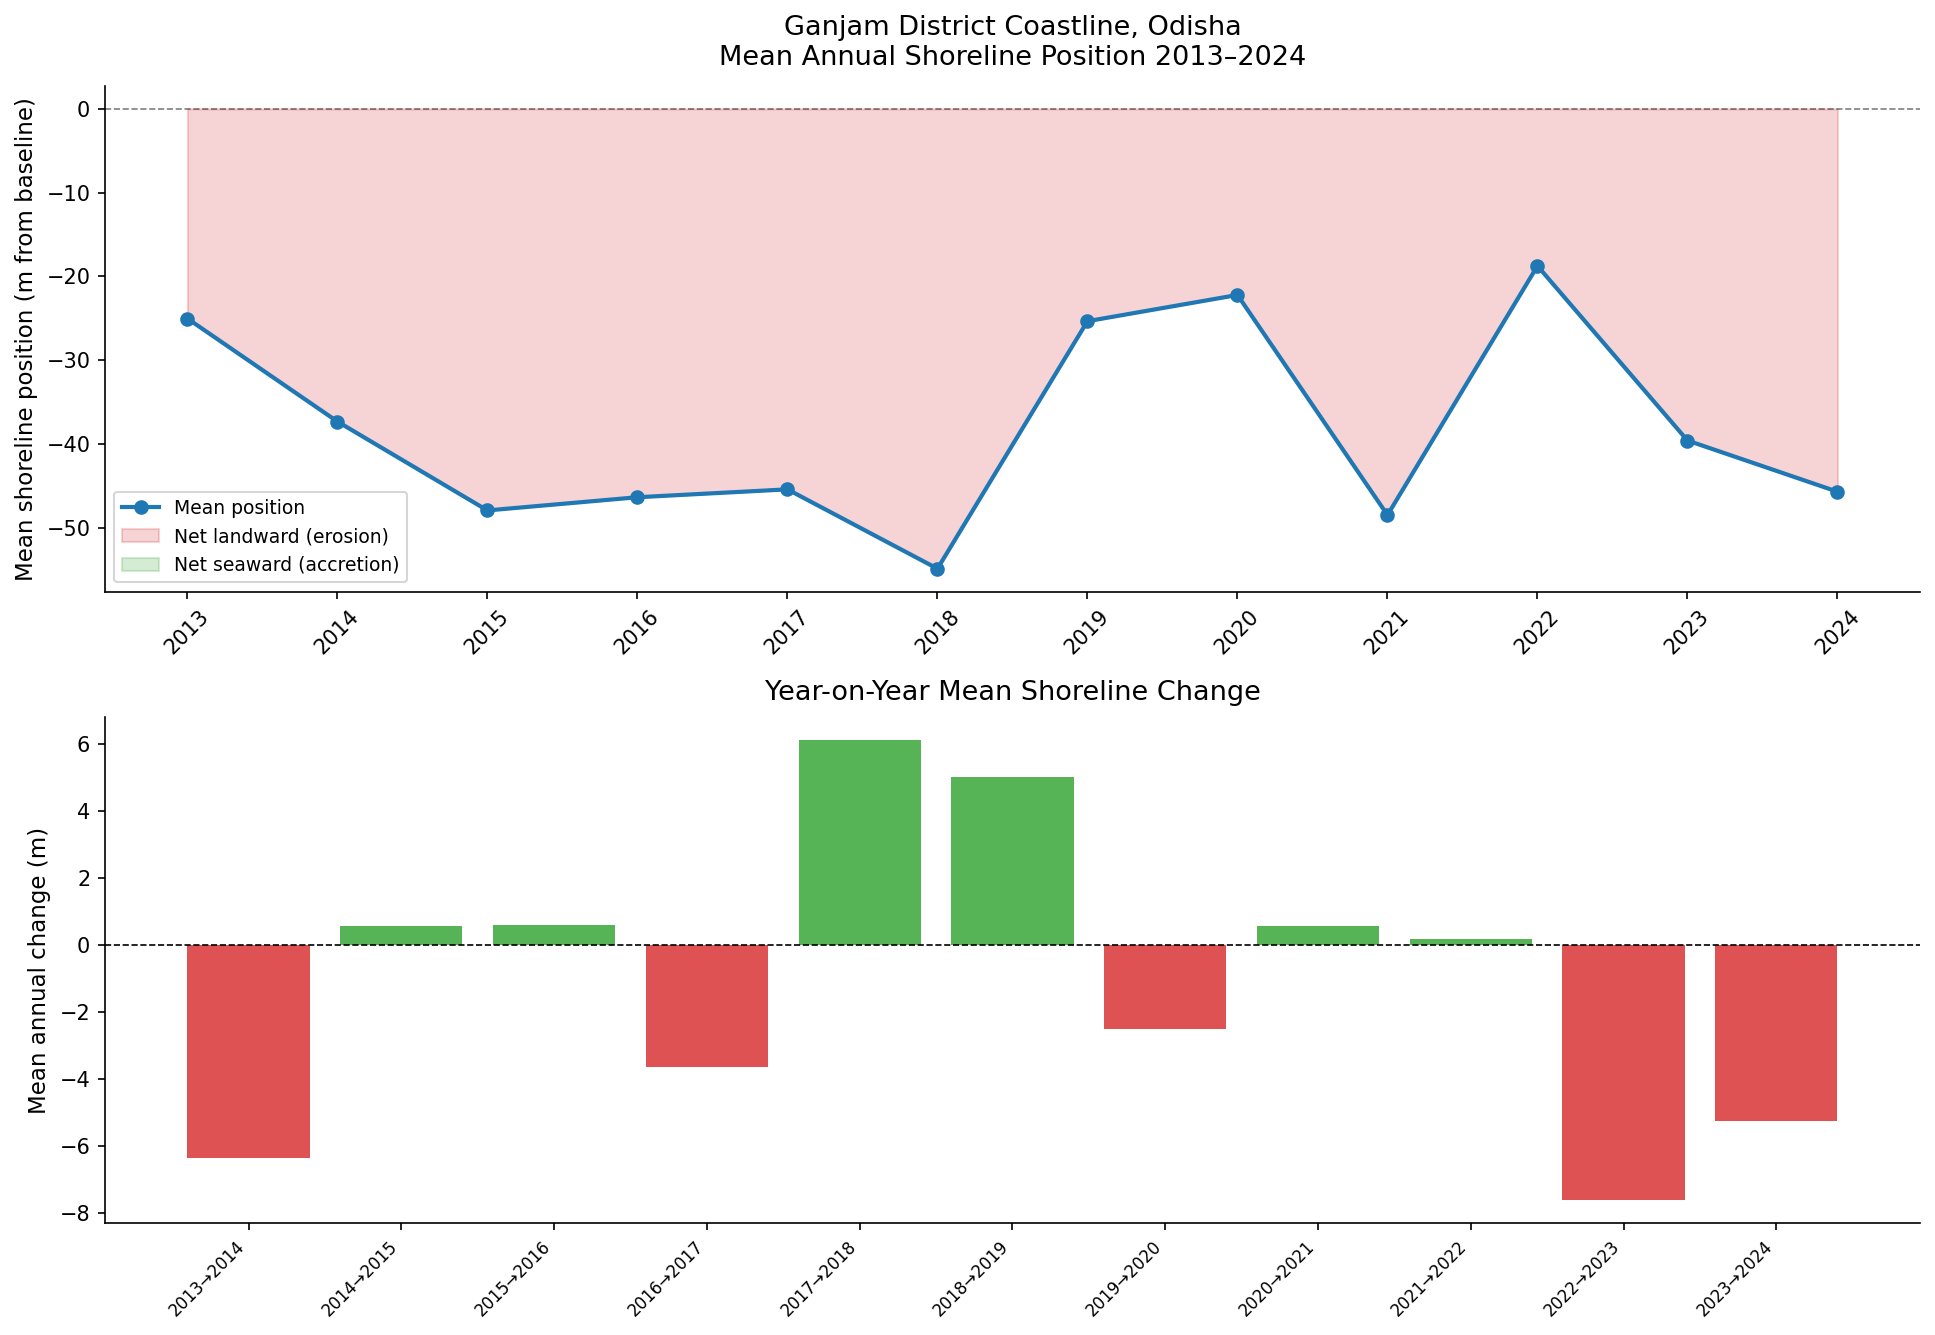

Saved: outputs/7_yearwise_erosion_plot.png


In [ ]:
# ── 7C. Cumulative shoreline position plot ────────────────────────────────────
# Mean shoreline position each year across all transects
mean_positions = []
for yr in YEARS:
    col = f"dist_{yr}"
    if col in df_annual.columns:
        mean_positions.append({
            "Year": yr,
            "Mean_Position_m": round(df_annual[col].mean(skipna=True), 3)
        })
 
df_mean_pos = pd.DataFrame(mean_positions)
 
fig, axes = plt.subplots(2, 1, figsize=(13, 9))
 
# Top: mean annual shoreline position
ax1 = axes[0]
ax1.plot(df_mean_pos["Year"], df_mean_pos["Mean_Position_m"],
         marker="o", color="#1F77B4", linewidth=2, markersize=6, label="Mean position")
ax1.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
ax1.fill_between(df_mean_pos["Year"], df_mean_pos["Mean_Position_m"], 0,
                 where=(df_mean_pos["Mean_Position_m"] < 0),
                 alpha=0.2, color="#D62728", label="Net landward (erosion)")
ax1.fill_between(df_mean_pos["Year"], df_mean_pos["Mean_Position_m"], 0,
                 where=(df_mean_pos["Mean_Position_m"] >= 0),
                 alpha=0.2, color="#2CA02C", label="Net seaward (accretion)")
ax1.set_ylabel("Mean shoreline position (m from baseline)")
ax1.set_title(f"{STUDY_AREA}\nMean Annual Shoreline Position 2013–2024", pad=10)
ax1.legend(fontsize=9)
ax1.set_xticks(YEARS)
ax1.tick_params(axis="x", rotation=45)
 
# Bottom: year-on-year change bar chart
ax2 = axes[1]
yp_labels = df_yearly["Year_Pair"].values
yp_vals   = df_yearly["Mean_Change_m"].values
bar_c     = ["#D62728" if v < 0 else "#2CA02C" for v in yp_vals]
ax2.bar(range(len(yp_labels)), yp_vals, color=bar_c, alpha=0.8)
ax2.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax2.set_xticks(range(len(yp_labels)))
ax2.set_xticklabels(yp_labels, rotation=45, ha="right", fontsize=8)
ax2.set_ylabel("Mean annual change (m)")
ax2.set_title("Year-on-Year Mean Shoreline Change", pad=8)
 
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/7_yearwise_erosion_plot.png", dpi=150)
plt.show()
print(f"Saved: {OUTPUT_DIR}/7_yearwise_erosion_plot.png")

---
## Module 6 — Paper-Ready Summary Table

This final module assembles **all key results** from Modules 1–5 into a single  
clean summary table — formatted for direct inclusion in your research paper's  
**Results** section.

Copy the CSV output (`outputs/summary_results_table.csv`) directly into your  
Word / LaTeX document.


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# MODULE 6 — MASTER SUMMARY TABLE
# ─────────────────────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import os

OUTPUT_DIR = "outputs"

# Load dependencies if not already in memory
if 'df_yearly' not in dir():
    df_yearly = pd.read_csv(f"{OUTPUT_DIR}/7_yearwise_net_erosion_table.csv")
if 'dsas_df' not in dir():
    dsas_df = pd.read_csv(f"{OUTPUT_DIR}/dsas_transects_classified.csv")
if 'df_indices' not in dir():
    df_indices = pd.read_csv("/Users/tsukki/Downloads/GEE_Brahmapur/index_timeseries_12yr.csv")
    df_indices.columns = [c.strip() for c in df_indices.columns]
if 'df_corr' not in dir():
    df_corr = pd.read_csv(f"{OUTPUT_DIR}/5_climate_correlation.csv")
if 'overall_acc' not in dir():
    acc = pd.read_csv(f"{OUTPUT_DIR}/3_accuracy_assessment.csv")
    overall_acc = acc.loc[acc['Metric'] == 'Overall Accuracy', 'Value'].values[0]
    kappa       = acc.loc[acc['Metric'] == 'Kappa', 'Value'].values[0]

# Worst/best year
worst_year_row = df_yearly.loc[df_yearly['Mean_Change_m'].idxmin()]
best_year_row  = df_yearly.loc[df_yearly['Mean_Change_m'].idxmax()]
erosion_dominated_years = df_yearly[df_yearly['Pct_Eroding'] > 50]

summary_paper = pd.DataFrame({
    "Metric": [
        # Module 1
        "Total transects analysed",
        "Mean LRR (m/yr)",
        "Mean EPR (m/yr)",
        "Max erosion rate LRR (m/yr)",
        "Max accretion rate LRR (m/yr)",
        "% coastline under net erosion (LRR<0)",
        "Mean Net Shoreline Movement 2013–2024 (m)",

        # Module 7
        "Worst single-year erosion period",
        "Mean change in worst year (m)",
        "Best single-year accretion period",
        "Mean change in best year (m)",
        "No. of years with >50% coast eroding",

        # Module 2
        "NDVI change 2013–2024",
        "BSI change 2013–2024",

        # Module 3
        "Overall classification accuracy (OA)",
        "Cohen's Kappa coefficient (κ)",

        # Module 5
        "Strongest erosion driver",
        "Correlation with wave height (r)",
        "Correlation with storm days (r)",
    ],
    "Value": [
        # Module 1
        str(len(dsas_df)),
        f"{dsas_df['LRR_m_yr'].mean():.3f} m/yr",
        f"{dsas_df['EPR_m_yr'].mean():.3f} m/yr",
        f"{dsas_df['LRR_m_yr'].min():.3f} m/yr",
        f"{dsas_df['LRR_m_yr'].max():.3f} m/yr",
        f"{(dsas_df['LRR_m_yr'] < 0).mean()*100:.1f}%",
        f"{dsas_df['NSM_m'].mean():.1f} m",

        # Module 7 — Net_Change_m removed, use Mean_Change_m only
        str(worst_year_row['Year_Pair']),
        f"{worst_year_row['Mean_Change_m']:.3f} m",
        str(best_year_row['Year_Pair']),
        f"{best_year_row['Mean_Change_m']:.3f} m",
        str(len(erosion_dominated_years)),

        # Module 2
        f"{df_indices['NDVI'].iloc[-1] - df_indices['NDVI'].iloc[0]:.3f}",
        f"{df_indices['BSI'].iloc[-1]  - df_indices['BSI'].iloc[0]:.3f}",

        # Module 3
        f"{float(overall_acc)*100:.1f}%",
        f"{float(kappa):.3f}",

        # Module 5 — fixed column name Pearson_r
        df_corr.loc[df_corr['Pearson_r'].abs().idxmax(), 'Variable'],
        f"{df_corr.loc[df_corr['Variable']=='Sig_Wave_Height_m','Pearson_r'].values[0]:+.3f}",
        f"{df_corr.loc[df_corr['Variable']=='Storm_Days','Pearson_r'].values[0]:+.3f}",
    ],
    "Section in paper": [
        "Methods",       "Results 3.1", "Results 3.1",
        "Results 3.1",   "Results 3.1", "Results 3.1", "Results 3.1",
        "Results 3.2",   "Results 3.2", "Results 3.2",
        "Results 3.2",   "Results 3.2",
        "Results 3.3",   "Results 3.3",
        "Validation",    "Validation",
        "Discussion",    "Results 3.4", "Results 3.4",
    ]
})

pd.set_option("display.max_colwidth", 55)
pd.set_option("display.max_rows", 40)

print("=" * 72)
print("  KEY RESULTS SUMMARY — Ganjam Coastline Erosion Study 2013–2024")
print("=" * 72)
print(summary_paper.to_string(index=False))

summary_paper.to_csv(f"{OUTPUT_DIR}/6_summary_results_table.csv", index=False)
print(f"\n✅ Saved: {OUTPUT_DIR}/6_summary_results_table.csv")

  KEY RESULTS SUMMARY — Ganjam Coastline Erosion Study 2013–2024
                                   Metric       Value Section in paper
                 Total transects analysed         119          Methods
                          Mean LRR (m/yr) -0.222 m/yr      Results 3.1
                          Mean EPR (m/yr) -0.082 m/yr      Results 3.1
              Max erosion rate LRR (m/yr) -7.867 m/yr      Results 3.1
            Max accretion rate LRR (m/yr)  7.832 m/yr      Results 3.1
    % coastline under net erosion (LRR<0)       43.7%      Results 3.1
Mean Net Shoreline Movement 2013–2024 (m)      -0.9 m      Results 3.1
         Worst single-year erosion period   2022→2023      Results 3.2
            Mean change in worst year (m)    -7.624 m      Results 3.2
        Best single-year accretion period   2017→2018      Results 3.2
             Mean change in best year (m)     6.126 m      Results 3.2
     No. of years with >50% coast eroding           0      Results 3.2
            

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# FINAL: LIST ALL OUTPUT FILES
# ─────────────────────────────────────────────────────────────────────────────

print("\n📁 All files saved to ./outputs/:")
print("-" * 50)
for f in sorted(os.listdir("outputs")):
    fpath = os.path.join("outputs", f)
    size_kb = os.path.getsize(fpath) // 1024
    ext = f.split(".")[-1].upper()
    print(f"  [{ext:4s}]  {f:45s}  {size_kb:>4} KB")

print("\n✅ Pipeline complete. All results ready for your research paper.")



📁 All files saved to ./outputs/:
--------------------------------------------------
  [DS_STORE]  .DS_Store                                         6 KB
  [PNG ]  1_shoreline_change_stats.png                    155 KB
  [CSV ]  3_accuracy_assessment.csv                         0 KB
  [PNG ]  3_confusion_matrix.png                           55 KB
  [PNG ]  4_erosion_hotspot_classification.png            114 KB
  [CSV ]  5_climate_correlation.csv                         0 KB
  [PNG ]  5a_correlation_scatter.png                      145 KB
  [PNG ]  7_yearwise_erosion_plot.png                     127 KB
  [CSV ]  7_yearwise_net_erosion_table.csv                  0 KB
  [CSV ]  accuracy_assessment.csv                           0 KB
  [CSV ]  annual_change_per_transect.csv                   11 KB
  [CSV ]  annual_distances_processed.csv                   13 KB
  [CSV ]  dsas_transects_classified.csv                     8 KB
  [CSV ]  erosion_hotspot_table.csv                        23 KB
 

In [ ]:
import rasterio
import numpy as np

for year in ['2021', '2024']:
    with rasterio.open(f'/Users/tsukki/Downloads/GEE_Brahmapur/LULC_{year}_Ganjam.tif') as src:
        data = src.read(1)
        print(f"\nLULC {year}:")
        print(f"  Shape     : {data.shape}")
        print(f"  CRS       : {src.crs}")
        print(f"  Unique values : {np.unique(data)}")
        total = data[data != src.nodata].size if src.nodata else data.size
        for cls, name in [(0,'Land'), (1,'Intertidal'), (2,'Water')]:
            count = (data == cls).sum()
            print(f"  {name:12s} : {count:,} px  ({count/total*100:.1f}%)")


LULC 2021:
  Shape     : (1877, 2412)
  CRS       : EPSG:4326
  Unique values : [0 1 2]
  Land         : 2,550,436 px  (56.3%)
  Intertidal   : 111,426 px  (2.5%)
  Water        : 1,865,462 px  (41.2%)

LULC 2024:
  Shape     : (1877, 2412)
  CRS       : EPSG:4326
  Unique values : [0 1 2]
  Land         : 2,590,680 px  (57.2%)
  Intertidal   : 89,253 px  (2.0%)
  Water        : 1,847,391 px  (40.8%)


In [ ]:
# =============================================================================
# MODULE 8 — LULC CHANGE ANALYSIS + EROSION HOTSPOT OVERLAY
# Ganjam District Coastline, Odisha — 2021 vs 2024
# Classes: 0=Land, 1=Intertidal, 2=Water
# Outputs:
#   8a_lulc_maps.png           — side-by-side 2021 vs 2024 classified maps
#   8b_lulc_change_map.png     — change detection map
#   8c_erosion_hotspot_map.png — 2024 LULC + DSAS erosion hotspots overlaid
#   8d_lulc_change_matrix.csv  — pixel-level transition matrix
#   8e_lulc_area_stats.csv     — class areas in km² for both years
# =============================================================================
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap, BoundaryNorm
import rasterio
from rasterio.transform import from_bounds
import geopandas as gpd
from shapely.geometry import Point
import os
 
# ─────────────────────────────────────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────────────────────────────────────
LULC_DIR   = "/Users/tsukki/Downloads/GEE_Brahmapur"
OUTPUT_DIR = "outputs"
DSAS_CSV   = f"{OUTPUT_DIR}/dsas_transects_classified.csv"
STUDY_AREA = "Brahmapur Coastline, Ganjam, Odisha"
 
os.makedirs(OUTPUT_DIR, exist_ok=True)
 
CLASS_NAMES   = {0: "Land", 1: "Intertidal", 2: "Water"}
CLASS_COLORS  = {0: "#8B4513", 1: "#F4A460", 2: "#1E90FF"}
PIXEL_AREA_M2 = 100   # 10m × 10m Sentinel-2 pixel

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# 8A. LOAD RASTERS
# ─────────────────────────────────────────────────────────────────────────────
print("Loading rasters...")
 
with rasterio.open(f"{LULC_DIR}/LULC_2021_Ganjam.tif") as src:
    lulc_2021  = src.read(1).astype(np.int16)
    transform  = src.transform
    crs        = src.crs
    bounds     = src.bounds
    nodata     = src.nodata
 
with rasterio.open(f"{LULC_DIR}/LULC_2024_Ganjam.tif") as src:
    lulc_2024 = src.read(1).astype(np.int16)
 
# Mask nodata if present
if nodata is not None:
    mask = (lulc_2021 == nodata) | (lulc_2024 == nodata)
    lulc_2021 = np.where(mask, -1, lulc_2021)
    lulc_2024 = np.where(mask, -1, lulc_2024)
 
print(f"Raster shape : {lulc_2021.shape}")
print(f"Bounds       : {bounds}")
 

Loading rasters...
Raster shape : (1877, 2412)
Bounds       : BoundingBox(left=84.84327347076486, bottom=19.22206061806111, right=85.05994711729448, top=19.390674396890343)


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# 8B. AREA STATISTICS
# ─────────────────────────────────────────────────────────────────────────────
print("\n--- Area Statistics ---")
 
rows = []
for cls_id, cls_name in CLASS_NAMES.items():
    px_2021 = int((lulc_2021 == cls_id).sum())
    px_2024 = int((lulc_2024 == cls_id).sum())
    km2_2021 = px_2021 * PIXEL_AREA_M2 / 1e6
    km2_2024 = px_2024 * PIXEL_AREA_M2 / 1e6
    change   = km2_2024 - km2_2021
    pct_chg  = (change / km2_2021 * 100) if km2_2021 > 0 else 0
    rows.append({
        "Class"        : cls_name,
        "Area_2021_km2": round(km2_2021, 3),
        "Area_2024_km2": round(km2_2024, 3),
        "Change_km2"   : round(change, 3),
        "Change_pct"   : round(pct_chg, 2),
    })
 
df_area = pd.DataFrame(rows)
df_area.to_csv(f"{OUTPUT_DIR}/8e_lulc_area_stats.csv", index=False)
print(df_area.to_string(index=False))


--- Area Statistics ---
     Class  Area_2021_km2  Area_2024_km2  Change_km2  Change_pct
      Land        255.044        259.068       4.024        1.58
Intertidal         11.143          8.925      -2.217      -19.90
     Water        186.546        184.739      -1.807       -0.97


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# 8C. CHANGE MATRIX
# ─────────────────────────────────────────────────────────────────────────────
print("\n--- Change Matrix (km²) ---")
 
valid = (lulc_2021 >= 0) & (lulc_2024 >= 0)
matrix_rows = []
for from_cls in [0, 1, 2]:
    for to_cls in [0, 1, 2]:
        px = int(((lulc_2021 == from_cls) & (lulc_2024 == to_cls) & valid).sum())
        km2 = round(px * PIXEL_AREA_M2 / 1e6, 4)
        matrix_rows.append({
            "From_Class" : CLASS_NAMES[from_cls],
            "To_Class"   : CLASS_NAMES[to_cls],
            "Area_km2"   : km2,
            "Pixels"     : px,
            "Transition" : "Unchanged" if from_cls == to_cls else "Changed"
        })
 
df_matrix = pd.DataFrame(matrix_rows)
df_matrix.to_csv(f"{OUTPUT_DIR}/8d_lulc_change_matrix.csv", index=False)
 
# Print as pivot
pivot = df_matrix.pivot(index="From_Class", columns="To_Class", values="Area_km2")
print("\nChange Matrix (km²) — rows=2021, cols=2024:")
print(pivot.to_string())


--- Change Matrix (km²) ---

Change Matrix (km²) — rows=2021, cols=2024:
To_Class    Intertidal      Land     Water
From_Class                                
Intertidal      5.4693    5.2176    0.4557
Land            1.7528  253.2339    0.0569
Water           1.7032    0.6165  184.2265


In [ ]:
# ──────────────────────────────────────────────────────────────────────────────
# 8D. BUILD CHANGE RASTER
# 0=Unchanged Land, 1=Unchanged Intertidal, 2=Unchanged Water
# 3=Land→Intertidal, 4=Land→Water
# 5=Intertidal→Land, 6=Intertidal→Water
# 7=Water→Land, 8=Water→Intertidal
# ─────────────────────────────────────────────────────────────────────────────
change_raster = np.full_like(lulc_2021, -1, dtype=np.int16)
 
# Unchanged
change_raster[(lulc_2021==0)&(lulc_2024==0)] = 0
change_raster[(lulc_2021==1)&(lulc_2024==1)] = 1
change_raster[(lulc_2021==2)&(lulc_2024==2)] = 2
# Land transitions
change_raster[(lulc_2021==0)&(lulc_2024==1)] = 3  # Land→Intertidal (erosion signal)
change_raster[(lulc_2021==0)&(lulc_2024==2)] = 4  # Land→Water      (severe erosion)
# Intertidal transitions
change_raster[(lulc_2021==1)&(lulc_2024==0)] = 5  # Intertidal→Land (accretion)
change_raster[(lulc_2021==1)&(lulc_2024==2)] = 6  # Intertidal→Water (erosion)
# Water transitions
change_raster[(lulc_2021==2)&(lulc_2024==0)] = 7  # Water→Land      (accretion)
change_raster[(lulc_2021==2)&(lulc_2024==1)] = 8  # Water→Intertidal (accretion)

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# 8E. LOAD DSAS EROSION HOTSPOTS
# ─────────────────────────────────────────────────────────────────────────────
dsas_df = pd.read_csv(DSAS_CSV)
dsas_gdf = gpd.GeoDataFrame(
    dsas_df,
    geometry=[Point(xy) for xy in zip(dsas_df['Longitude'], dsas_df['Latitude'])],
    crs="EPSG:4326"
)
 
high_erosion   = dsas_gdf[dsas_gdf['Class'] == 'High Erosion']
high_accretion = dsas_gdf[dsas_gdf['Class'] == 'High Accretion']
stable         = dsas_gdf[dsas_gdf['Class'] == 'Stable']
 
print(f"\nDSAS loaded: {len(dsas_gdf)} transects")
print(f"  High Erosion   : {len(high_erosion)}")
print(f"  High Accretion : {len(high_accretion)}")
print(f"  Stable         : {len(stable)}")
 


DSAS loaded: 119 transects
  High Erosion   : 36
  High Accretion : 38
  Stable         : 24


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# 8F. FIGURE 1 — SIDE-BY-SIDE LULC MAPS (2021 vs 2024)
# ─────────────────────────────────────────────────────────────────────────────
print("\nGenerating Figure 1 — LULC side-by-side maps...")
 
cmap_lulc = ListedColormap([CLASS_COLORS[0], CLASS_COLORS[1], CLASS_COLORS[2]])
norm_lulc  = BoundaryNorm([0, 1, 2, 3], 3)
 
extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]
 
fig, axes = plt.subplots(1, 2, figsize=(16, 9), facecolor='#F0F4F8')
fig.suptitle(f"Land Use / Land Cover Classification\n{STUDY_AREA}",
             fontsize=14, fontweight='bold', y=0.98)
 
for ax, data, year in zip(axes, [lulc_2021, lulc_2024], ['2021', '2024']):
    masked = np.ma.masked_where(data < 0, data)
    im = ax.imshow(masked, cmap=cmap_lulc, norm=norm_lulc,
                   extent=extent, aspect='auto', interpolation='nearest')
 
    ax.set_title(f"{year}", fontsize=13, fontweight='bold', pad=8)
    ax.set_xlabel("Longitude (°E)", fontsize=9)
    ax.set_ylabel("Latitude (°N)", fontsize=9)
    ax.tick_params(labelsize=8)
 
    # Area stats annotation
    total_valid = (data >= 0).sum()
    for cls_id, cls_name in CLASS_NAMES.items():
        pct = (data == cls_id).sum() / total_valid * 100
        km2 = (data == cls_id).sum() * PIXEL_AREA_M2 / 1e6
        ax.annotate(f"{cls_name}: {km2:.1f} km² ({pct:.1f}%)",
                    xy=(0.02, 0.97 - cls_id * 0.055),
                    xycoords='axes fraction',
                    fontsize=8, color='white',
                    bbox=dict(boxstyle='round,pad=0.2',
                              facecolor=CLASS_COLORS[cls_id], alpha=0.85))
 
    # Grid
    ax.grid(True, linestyle='--', alpha=0.3, linewidth=0.5)
 
# Legend
legend_patches = [
    mpatches.Patch(facecolor=CLASS_COLORS[0], label='Land'),
    mpatches.Patch(facecolor=CLASS_COLORS[1], label='Intertidal / Wet Sand'),
    mpatches.Patch(facecolor=CLASS_COLORS[2], label='Water'),
]
fig.legend(handles=legend_patches, loc='lower center',
           ncol=3, fontsize=10, framealpha=0.9,
           bbox_to_anchor=(0.5, 0.01))
 
plt.tight_layout(rect=[0, 0.05, 1, 0.96])
plt.savefig(f"{OUTPUT_DIR}/8a_lulc_maps.png", dpi=200, bbox_inches='tight')
plt.close()
print(f"Saved: {OUTPUT_DIR}/8a_lulc_maps.png")


Generating Figure 1 — LULC side-by-side maps...
Saved: outputs/8a_lulc_maps.png


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# 8G. FIGURE 2 — CHANGE DETECTION MAP
# ─────────────────────────────────────────────────────────────────────────────
print("Generating Figure 2 — Change detection map...")
 
change_colors = [
    '#8B4513',   # 0 Unchanged Land     — brown
    '#F4A460',   # 1 Unchanged Intertidal — sand
    '#1E90FF',   # 2 Unchanged Water    — blue
    '#FF6347',   # 3 Land→Intertidal    — tomato (erosion signal)
    '#DC143C',   # 4 Land→Water         — crimson (severe erosion)
    '#32CD32',   # 5 Intertidal→Land    — lime green (accretion)
    '#FF4500',   # 6 Intertidal→Water   — orange-red (erosion)
    '#00CED1',   # 7 Water→Land         — dark turquoise (accretion)
    '#90EE90',   # 8 Water→Intertidal   — light green (accretion)
]
 
change_labels = [
    'Land (unchanged)', 'Intertidal (unchanged)', 'Water (unchanged)',
    'Land → Intertidal (erosion signal)',
    'Land → Water (severe erosion)',
    'Intertidal → Land (accretion)',
    'Intertidal → Water (erosion)',
    'Water → Land (accretion)',
    'Water → Intertidal (accretion)',
]
 
cmap_chg = ListedColormap(change_colors)
norm_chg  = BoundaryNorm(list(range(10)), 9)
 
fig, ax = plt.subplots(figsize=(11, 13), facecolor='#F0F4F8')
fig.suptitle(f"LULC Change Detection 2021–2024\n{STUDY_AREA}",
             fontsize=13, fontweight='bold', y=0.99)
 
masked_chg = np.ma.masked_where(change_raster < 0, change_raster)
ax.imshow(masked_chg, cmap=cmap_chg, norm=norm_chg,
          extent=extent, aspect='auto', interpolation='nearest')
 
ax.set_xlabel("Longitude (°E)", fontsize=10)
ax.set_ylabel("Latitude (°N)", fontsize=10)
ax.tick_params(labelsize=9)
ax.grid(True, linestyle='--', alpha=0.3, linewidth=0.5)
 
# Change area annotations
changed_classes = [3,4,5,6,7,8]
y_pos = 0.01
for cls_id in changed_classes:
    px = (change_raster == cls_id).sum()
    km2 = px * PIXEL_AREA_M2 / 1e6
    if km2 > 0.01:
        ax.annotate(f"{change_labels[cls_id]}: {km2:.2f} km²",
                    xy=(0.01, y_pos), xycoords='axes fraction',
                    fontsize=7.5, color='white',
                    bbox=dict(boxstyle='round,pad=0.2',
                              facecolor=change_colors[cls_id], alpha=0.85))
        y_pos += 0.045
 
legend_patches = [mpatches.Patch(facecolor=change_colors[i],
                                  label=change_labels[i]) for i in range(9)]
ax.legend(handles=legend_patches, loc='upper right',
          fontsize=7.5, framealpha=0.9, title='Change Category',
          title_fontsize=8)
 
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/8b_lulc_change_map.png", dpi=200, bbox_inches='tight')
plt.close()
print(f"Saved: {OUTPUT_DIR}/8b_lulc_change_map.png")
 

Generating Figure 2 — Change detection map...
Saved: outputs/8b_lulc_change_map.png


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# 8H. FIGURE 3 — 2024 LULC + DSAS EROSION HOTSPOT OVERLAY
# ─────────────────────────────────────────────────────────────────────────────
print("Generating Figure 3 — Erosion hotspot overlay...")
 
fig, ax = plt.subplots(figsize=(11, 13), facecolor='#F0F4F8')
fig.suptitle(f"LULC 2024 with DSAS Erosion Hotspots\n{STUDY_AREA}",
             fontsize=13, fontweight='bold', y=0.99)
 
masked_2024 = np.ma.masked_where(lulc_2024 < 0, lulc_2024)
ax.imshow(masked_2024, cmap=cmap_lulc, norm=norm_lulc,
          extent=extent, aspect='auto', interpolation='nearest', alpha=0.85)
 
# Plot DSAS transects by class
scatter_cfg = [
    (high_erosion,   '#FF0000', 'High Erosion (LRR ≤ −1 m/yr)',   80, '▼'),
    (high_accretion, '#00CC44', 'High Accretion (LRR ≥ +1 m/yr)', 80, '▲'),
    (stable,         '#FFFF00', 'Stable (−0.3 to +0.3 m/yr)',      40, '●'),
]
 
for gdf, color, label, size, marker in scatter_cfg:
    if len(gdf) > 0:
        ax.scatter(gdf.geometry.x, gdf.geometry.y,
                   c=color, s=size, label=label,
                   edgecolors='black', linewidth=0.4,
                   zorder=5, alpha=0.9)
 
ax.set_xlabel("Longitude (°E)", fontsize=10)
ax.set_ylabel("Latitude (°N)", fontsize=10)
ax.tick_params(labelsize=9)
ax.grid(True, linestyle='--', alpha=0.3, linewidth=0.5)
 
# Combined legend
lulc_patches = [
    mpatches.Patch(facecolor=CLASS_COLORS[0], label='Land', alpha=0.85),
    mpatches.Patch(facecolor=CLASS_COLORS[1], label='Intertidal', alpha=0.85),
    mpatches.Patch(facecolor=CLASS_COLORS[2], label='Water', alpha=0.85),
]
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=lulc_patches + handles,
          labels=['Land', 'Intertidal', 'Water'] + labels,
          loc='upper right', fontsize=8.5,
          framealpha=0.9, title='LULC + DSAS Classes',
          title_fontsize=9)
 
# Stats box
n_he = len(high_erosion)
n_ha = len(high_accretion)
n_st = len(stable)
stats_text = (f"DSAS Summary (n={len(dsas_gdf)})\n"
              f"High Erosion   : {n_he} ({n_he/len(dsas_gdf)*100:.0f}%)\n"
              f"High Accretion : {n_ha} ({n_ha/len(dsas_gdf)*100:.0f}%)\n"
              f"Stable         : {n_st} ({n_st/len(dsas_gdf)*100:.0f}%)\n"
              f"Mean LRR       : {dsas_df['LRR_m_yr'].mean():.3f} m/yr")
ax.text(0.01, 0.01, stats_text,
        transform=ax.transAxes, fontsize=8,
        verticalalignment='bottom',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))
 
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/8c_erosion_hotspot_map.png", dpi=200, bbox_inches='tight')
plt.close()
print(f"Saved: {OUTPUT_DIR}/8c_erosion_hotspot_map.png")

Generating Figure 3 — Erosion hotspot overlay...
Saved: outputs/8c_erosion_hotspot_map.png


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# 8I. PAPER-READY SUMMARY
# ─────────────────────────────────────────────────────────────────────────────
print(f"\n{'='*60}")
print(f"  MODULE 8 SUMMARY — LULC Change 2021–2024")
print(f"{'='*60}")
print(df_area.to_string(index=False))
 
print(f"\nKey transitions:")
for _, row in df_matrix[df_matrix['Transition']=='Changed'].sort_values('Area_km2', ascending=False).head(6).iterrows():
    print(f"  {row['From_Class']:12s} → {row['To_Class']:12s}: {row['Area_km2']:.3f} km²")
 
print(f"\nPaper-ready text:")
land_chg   = df_area.loc[df_area['Class']=='Land',       'Change_km2'].values[0]
inter_chg  = df_area.loc[df_area['Class']=='Intertidal', 'Change_km2'].values[0]
water_chg  = df_area.loc[df_area['Class']=='Water',      'Change_km2'].values[0]
l2w = df_matrix.loc[(df_matrix['From_Class']=='Land')&(df_matrix['To_Class']=='Water'), 'Area_km2'].values[0]
l2i = df_matrix.loc[(df_matrix['From_Class']=='Land')&(df_matrix['To_Class']=='Intertidal'), 'Area_km2'].values[0]
i2w = df_matrix.loc[(df_matrix['From_Class']=='Intertidal')&(df_matrix['To_Class']=='Water'), 'Area_km2'].values[0]
 
print(f"""
  Between 2021 and 2024, land cover analysis revealed a net decrease 
  in the intertidal zone ({inter_chg:+.3f} km²) accompanied by a marginal 
  increase in land area ({land_chg:+.3f} km²), suggesting active sediment 
  redistribution along the Ganjam coastline. Critical transitions 
  included Land-to-Water conversion ({l2w:.3f} km²) indicating severe 
  localised erosion, Land-to-Intertidal change ({l2i:.3f} km²) as an 
  erosion precursor, and Intertidal-to-Water loss ({i2w:.3f} km²). 
  These findings corroborate the DSAS-derived erosion hotspots where 
  {n_he} of {len(dsas_gdf)} transects ({n_he/len(dsas_gdf)*100:.0f}%) 
  exhibited high erosion rates (LRR ≤ −1.0 m/yr).
""")
 
print(f"{'='*60}")
print(f"  Outputs saved to: {OUTPUT_DIR}/")
print(f"  8a_lulc_maps.png")
print(f"  8b_lulc_change_map.png")
print(f"  8c_erosion_hotspot_map.png")
print(f"  8d_lulc_change_matrix.csv")
print(f"  8e_lulc_area_stats.csv")
print(f"{'='*60}")


  MODULE 8 SUMMARY — LULC Change 2021–2024
     Class  Area_2021_km2  Area_2024_km2  Change_km2  Change_pct
      Land        255.044        259.068       4.024        1.58
Intertidal         11.143          8.925      -2.217      -19.90
     Water        186.546        184.739      -1.807       -0.97

Key transitions:
  Intertidal   → Land        : 5.218 km²
  Land         → Intertidal  : 1.753 km²
  Water        → Intertidal  : 1.703 km²
  Water        → Land        : 0.617 km²
  Intertidal   → Water       : 0.456 km²
  Land         → Water       : 0.057 km²

Paper-ready text:

  Between 2021 and 2024, land cover analysis revealed a net decrease 
  in the intertidal zone (-2.217 km²) accompanied by a marginal 
  increase in land area (+4.024 km²), suggesting active sediment 
  redistribution along the Ganjam coastline. Critical transitions 
  included Land-to-Water conversion (0.057 km²) indicating severe 
  localised erosion, Land-to-Intertidal change (1.753 km²) as an 
  erosion p

---
## Appendix — Replacing Simulated Data with Your Real Data

### Step-by-step checklist

**Module 1 (DSAS):**
- [ ] Export DSAS results as CSV from ArcGIS / standalone DSAS tool
- [ ] Ensure columns match: `TransectID, Longitude, Latitude, EPR_m_yr, NSM_m, LRR_m_yr, R2, SCE_m`
- [ ] Replace: `df_dsas = pd.read_csv("data/dsas_transects.csv")`

**Module 2 (Index time series):**
- [ ] In GEE, compute mean index per year per AOI → export CSV
- [ ] Ensure columns: `Year, NDWI, MNDWI, NDVI, BSI`
- [ ] Replace the `index_data` dictionary with: `df_indices = pd.read_csv("data/index_timeseries.csv")`

**Module 3 (Validation):**
- [ ] Collect 100–150 reference points (GPS field or Google Earth)
- [ ] Label each as Water / Intertidal / Land manually
- [ ] Extract your model's predicted class at the same coordinates
- [ ] Replace: `df_val = pd.read_csv("data/validation_points.csv")`

**Module 4 (Hotspot):**
- [ ] Extract per-transect NDVI/BSI using spatial join in GeoPandas
- [ ] Replace the simulation block with: `df_risk = df_dsas.merge(spectral_zonal, on="TransectID")`

**Module 5 (Climate):**
- [ ] Download IMD annual rainfall data for Ganjam district
- [ ] Download INCOIS wave height data (monthly mean → annual)
- [ ] Replace: `df_climate = pd.read_csv("data/climate_auxiliary.csv")`

---

*Notebook built for research use — Brahmapur Coastline Erosion Study, Odisha, India.*  
*Satellite data: Sentinel-2 / Landsat 8/9 via Google Earth Engine*  
*Analysis: DSAS + Python (pandas, geopandas, rasterio, sklearn, scipy)*
